# 12 — Analisis Kesalahan Model Klasifikasi Jenis Awan

Notebook ini melakukan analisis mendalam terhadap kesalahan prediksi model
pada test split Ground-based Cloud Dataset (GCD).

Analisis menggunakan artefak yang telah dihasilkan oleh:

- `10_pengujian_model.ipynb`
- `11_evaluasi_model.ipynb`

Ruang lingkup analisis meliputi:

1. jumlah dan distribusi kesalahan;
2. kesalahan setiap kelas;
3. pasangan kelas yang paling sering tertukar;
4. kesalahan dengan confidence tinggi;
5. prediksi ambigu berdasarkan confidence margin;
6. karakteristik visual citra yang berkaitan dengan kesalahan;
7. visualisasi contoh citra salah klasifikasi;
8. penyimpanan laporan dan metadata analisis.

Notebook ini tidak melakukan:

- training ulang;
- pemilihan checkpoint;
- inference ulang;
- perubahan bobot model;
- tuning hyperparameter menggunakan test split.

Test split hanya digunakan untuk diagnosis akhir model. Hasil analisis tidak boleh
digunakan langsung untuk menyesuaikan model menggunakan data test karena dapat
menimbulkan kebocoran informasi.

In [46]:
from pathlib import Path
from datetime import datetime

import hashlib
import json
import math
import re
import sys
import warnings

try:
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns

    from IPython.display import display
    from PIL import Image, ImageOps

except ImportError as exc:
    raise ImportError(
        "Dependency analisis kesalahan belum lengkap.\n\n"
        "Aktifkan .venv, kemudian jalankan melalui terminal VS Code:\n\n"
        r".\.venv\Scripts\python.exe -m pip install -r requirements.txt"
    ) from exc


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.precision", 6)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)


print(f"Python     : {sys.version.split()[0]}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print("Tahap      : Analisis kesalahan model")
print("Inference  : Tidak dijalankan")
print("Training   : Tidak dijalankan")

Python     : 3.11.9
NumPy      : 2.4.6
Pandas     : 3.0.5
Tahap      : Analisis kesalahan model
Inference  : Tidak dijalankan
Training   : Tidak dijalankan


In [47]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
SOURCE_DIR = DATASET_DIR / "source"
PROCESSED_DIR = DATASET_DIR / "processed"

TEST_DIR = SOURCE_DIR / "test"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

MODEL_CONFIG_PATH = (
    PROCESSED_DIR
    / "model_config.json"
)


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "PROCESSED_DIR",
        "TEST_DIR",
        "MODELS_DIR",
        "LOGS_DIR",
        "MODEL_CONFIG_PATH",
    ],
    "Path": [
        PROJECT_DIR,
        PROCESSED_DIR,
        TEST_DIR,
        MODELS_DIR,
        LOGS_DIR,
        MODEL_CONFIG_PATH,
    ],
})

path_table["Ada"] = (
    path_table["Path"]
    .map(Path.exists)
)


display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,D:\n8n-logsiswaparalayang\cloud-classification,True
1,PROCESSED_DIR,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed,True
2,TEST_DIR,D:\n8n-logsiswaparalayang\cloud-classification\dataset\source\test,True
3,MODELS_DIR,D:\n8n-logsiswaparalayang\cloud-classification\models,True
4,LOGS_DIR,D:\n8n-logsiswaparalayang\cloud-classification\logs,True
5,MODEL_CONFIG_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\model_config.json,True


In [48]:
required_directories = [
    PROJECT_DIR,
    PROCESSED_DIR,
    TEST_DIR,
    LOGS_DIR,
]


missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]


if missing_directories:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        "Folder prasyarat belum tersedia:\n"
        f"{formatted_paths}"
    )


if not MODEL_CONFIG_PATH.is_file():
    raise FileNotFoundError(
        "Konfigurasi model tidak ditemukan:\n"
        f"{MODEL_CONFIG_PATH}\n\n"
        "Pastikan 07_persiapan_model.ipynb telah selesai dijalankan."
    )


print("Seluruh folder dan konfigurasi dasar tersedia.")

Seluruh folder dan konfigurasi dasar tersedia.


In [49]:
with MODEL_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    model_config = json.load(file)


required_model_keys = {
    "model_name",
    "num_classes",
    "class_to_idx",
    "input_shape",
}


missing_model_keys = (
    required_model_keys
    - set(model_config.keys())
)


if missing_model_keys:
    raise KeyError(
        "model_config.json belum lengkap. "
        f"Kunci yang hilang: {sorted(missing_model_keys)}"
    )


MODEL_NAME = str(
    model_config["model_name"]
)

NUM_CLASSES = int(
    model_config["num_classes"]
)

CLASS_TO_IDX = {
    str(class_name): int(class_id)
    for class_name, class_id
    in model_config["class_to_idx"].items()
}

IDX_TO_CLASS = {
    class_id: class_name
    for class_name, class_id
    in CLASS_TO_IDX.items()
}

LABEL_IDS = np.arange(
    NUM_CLASSES,
    dtype=np.int64,
)

CLASS_NAMES = [
    IDX_TO_CLASS[class_id]
    for class_id in LABEL_IDS
]

SAFE_MODEL_NAME = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MODEL_NAME,
)


configuration_table = pd.DataFrame({
    "Parameter": [
        "Nama model",
        "Jumlah kelas",
        "Input shape",
        "Urutan kelas",
    ],
    "Nilai": [
        MODEL_NAME,
        NUM_CLASSES,
        model_config["input_shape"],
        CLASS_NAMES,
    ],
})


display(configuration_table)

,Parameter,Nilai
0,Nama model,resnet50
1,Jumlah kelas,7
2,Input shape,"[3, 224, 224]"
3,Urutan kelas,"[1_cumulus, 2_altocumulus, 3_cirrus, 4_clearsky, 5_stratocumulus, 6_cumulonimbus, 7_mixed]"


In [50]:
def read_json(
    path: Path,
) -> dict:
    """
    Membaca JSON dan memastikan hasilnya berupa dictionary.
    """
    with path.open(
        "r",
        encoding="utf-8",
    ) as file:
        data = json.load(file)

    if not isinstance(data, dict):
        raise TypeError(
            f"Isi JSON harus berupa dictionary: {path}"
        )

    return data


def normalize_boolean_series(
    series: pd.Series,
) -> pd.Series:
    """
    Mengubah nilai boolean dari CSV menjadi dtype bool.
    """
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
    )

    if normalized.isna().any():
        invalid_values = (
            series.loc[normalized.isna()]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            "Nilai boolean tidak dikenali: "
            f"{invalid_values}"
        )

    return normalized.astype(bool)


def calculate_sha256(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """
    Menghitung SHA-256 tanpa memuat seluruh file ke memori.
    """
    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


def resolve_project_path(
    recorded_path,
) -> Path:
    """
    Mengubah path relatif pada metadata menjadi path absolut project.
    """
    path = Path(recorded_path)

    if path.is_absolute():
        return path.resolve()

    return (
        PROJECT_DIR
        / path
    ).resolve()


def select_complete_run(
    parent_directory: Path,
    pattern: str,
    required_files: list[str],
    selected_run=None,
) -> Path:
    """
    Memilih run terbaru yang memiliki seluruh artefak wajib.
    """
    if selected_run is not None:
        selected_path = resolve_project_path(
            selected_run
        )

        if not selected_path.is_dir():
            raise FileNotFoundError(
                "Folder run yang dipilih tidak ditemukan:\n"
                f"{selected_path}"
            )

        missing_files = [
            file_name
            for file_name in required_files
            if not (
                selected_path
                / file_name
            ).is_file()
        ]

        if missing_files:
            raise FileNotFoundError(
                "Folder run belum lengkap. "
                f"File yang hilang: {missing_files}"
            )

        return selected_path


    candidate_directories = sorted(
        [
            path
            for path in parent_directory.glob(pattern)
            if path.is_dir()
        ],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )


    for candidate_directory in candidate_directories:
        complete = all(
            (
                candidate_directory
                / file_name
            ).is_file()
            for file_name in required_files
        )

        if complete:
            return candidate_directory


    raise FileNotFoundError(
        "Tidak ditemukan run lengkap untuk pola:\n"
        f"{pattern}"
    )


print("Fungsi pendukung berhasil didefinisikan.")

Fungsi pendukung berhasil didefinisikan.


## Memilih Run Evaluasi

Secara default notebook memilih folder evaluasi terbaru yang lengkap.

Apabila ingin menganalisis run tertentu, isi `SELECTED_EVALUATION_RUN`
dengan path relatif dari project, misalnya:

`logs/efficientnet_b0_evaluation_20260826_120000_000000`

In [51]:
SELECTED_EVALUATION_RUN = None

In [52]:
EVALUATION_REQUIRED_FILES = [
    "model_evaluation_summary.json",
    "model_evaluation_report.md",
    "dominant_error_pairs.csv",
    "per_class_generalization.csv",
]


EVALUATION_RUN_DIR = select_complete_run(
    parent_directory=LOGS_DIR,
    pattern=f"{SAFE_MODEL_NAME}_evaluation_*",
    required_files=EVALUATION_REQUIRED_FILES,
    selected_run=SELECTED_EVALUATION_RUN,
)


EVALUATION_SUMMARY_PATH = (
    EVALUATION_RUN_DIR
    / "model_evaluation_summary.json"
)


print(
    "Run evaluasi yang digunakan:\n"
    f"{EVALUATION_RUN_DIR.relative_to(PROJECT_DIR)}"
)

Run evaluasi yang digunakan:
logs\resnet50_evaluation_20260826_233246_842963


In [53]:
evaluation_summary = read_json(
    EVALUATION_SUMMARY_PATH
)


required_evaluation_keys = {
    "stage",
    "model",
    "selected_runs",
    "sample_counts",
    "test_metrics",
    "evaluation_design",
}


missing_evaluation_keys = (
    required_evaluation_keys
    - set(evaluation_summary.keys())
)


if missing_evaluation_keys:
    raise KeyError(
        "Ringkasan evaluasi belum lengkap. "
        f"Kunci yang hilang: {sorted(missing_evaluation_keys)}"
    )


TEST_RUN_DIR = resolve_project_path(
    evaluation_summary[
        "selected_runs"
    ][
        "test"
    ]
)


TEST_PREDICTIONS_PATH = (
    TEST_RUN_DIR
    / "test_predictions.csv"
)

TEST_METRICS_PATH = (
    TEST_RUN_DIR
    / "test_metrics.json"
)

TEST_PER_CLASS_PATH = (
    TEST_RUN_DIR
    / "test_per_class_metrics.csv"
)

TEST_ERROR_PAIRS_PATH = (
    TEST_RUN_DIR
    / "test_error_pairs.csv"
)


input_artifact_table = pd.DataFrame({
    "Artefak": [
        "Konfigurasi model",
        "Ringkasan evaluasi",
        "Prediksi test",
        "Metrik test",
        "Metrik per kelas",
        "Pasangan kesalahan test",
    ],
    "Path": [
        MODEL_CONFIG_PATH,
        EVALUATION_SUMMARY_PATH,
        TEST_PREDICTIONS_PATH,
        TEST_METRICS_PATH,
        TEST_PER_CLASS_PATH,
        TEST_ERROR_PAIRS_PATH,
    ],
})

input_artifact_table["Ada"] = (
    input_artifact_table["Path"]
    .map(Path.is_file)
)


display(input_artifact_table)


if not input_artifact_table["Ada"].all():
    missing_artifacts = (
        input_artifact_table
        .loc[
            ~input_artifact_table["Ada"],
            "Path",
        ]
        .tolist()
    )

    raise FileNotFoundError(
        "Artefak pengujian belum lengkap:\n- "
        + "\n- ".join(
            str(path)
            for path in missing_artifacts
        )
    )

,Artefak,Path,Ada
0,Konfigurasi model,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\model_config.json,True
1,Ringkasan evaluasi,D:\n8n-logsiswaparalayang\cloud-classification\logs\resnet50_evaluation_20260826_233246_842963\model_evaluation_summary.json,True
2,Prediksi test,D:\n8n-logsiswaparalayang\cloud-classification\logs\resnet50_final_test_20260826_232648\test_predictions.csv,True
3,Metrik test,D:\n8n-logsiswaparalayang\cloud-classification\logs\resnet50_final_test_20260826_232648\test_metrics.json,True
4,Metrik per kelas,D:\n8n-logsiswaparalayang\cloud-classification\logs\resnet50_final_test_20260826_232648\test_per_class_metrics.csv,True
5,Pasangan kesalahan test,D:\n8n-logsiswaparalayang\cloud-classification\logs\resnet50_final_test_20260826_232648\test_error_pairs.csv,True


In [54]:
test_summary = read_json(
    TEST_METRICS_PATH
)

test_predictions_df = pd.read_csv(
    TEST_PREDICTIONS_PATH
)

test_per_class_source_df = pd.read_csv(
    TEST_PER_CLASS_PATH
)

test_error_pairs_source_df = pd.read_csv(
    TEST_ERROR_PAIRS_PATH
)


required_prediction_columns = {
    "sample_id",
    "image_path",
    "true_id",
    "true_class",
    "predicted_id",
    "predicted_class",
    "confidence",
    "confidence_margin",
    "correct",
}


missing_prediction_columns = (
    required_prediction_columns
    - set(test_predictions_df.columns)
)


if missing_prediction_columns:
    raise KeyError(
        "Kolom test_predictions.csv belum lengkap:\n- "
        + "\n- ".join(
            sorted(missing_prediction_columns)
        )
    )


test_predictions_df["correct"] = (
    normalize_boolean_series(
        test_predictions_df["correct"]
    )
)

test_predictions_df["true_id"] = pd.to_numeric(
    test_predictions_df["true_id"],
    errors="raise",
).astype(int)

test_predictions_df["predicted_id"] = pd.to_numeric(
    test_predictions_df["predicted_id"],
    errors="raise",
).astype(int)

test_predictions_df["confidence"] = pd.to_numeric(
    test_predictions_df["confidence"],
    errors="raise",
).astype(float)

test_predictions_df["confidence_margin"] = pd.to_numeric(
    test_predictions_df["confidence_margin"],
    errors="raise",
).astype(float)


print(
    "Jumlah prediksi test : "
    f"{len(test_predictions_df):,}"
)

display(
    test_predictions_df.head()
)

Jumlah prediksi test : 9,000


,sample_id,image_path,file_name,true_id,true_class,predicted_id,predicted_class,confidence,second_confidence,confidence_margin,top_classes,top_probabilities,correct
0,0,dataset\source\test\1_cumulus\1_cumulus_000776.jpg,1_cumulus_000776.jpg,0,1_cumulus,4,5_stratocumulus,0.321625,0.310940,0.010685,5_stratocumulus | 6_cumulonimbus | 1_cumulus,0.321625 | 0.310940 | 0.205423,False
1,1,dataset\source\test\1_cumulus\1_cumulus_000777.jpg,1_cumulus_000777.jpg,0,1_cumulus,5,6_cumulonimbus,0.429800,0.146321,0.283478,6_cumulonimbus | 3_cirrus | 1_cumulus,0.429800 | 0.146321 | 0.128947,False
2,2,dataset\source\test\1_cumulus\1_cumulus_000778.jpg,1_cumulus_000778.jpg,0,1_cumulus,5,6_cumulonimbus,0.559347,0.263426,0.295921,6_cumulonimbus | 1_cumulus | 7_mixed,0.559347 | 0.263426 | 0.073029,False
3,3,dataset\source\test\1_cumulus\1_cumulus_000779.jpg,1_cumulus_000779.jpg,0,1_cumulus,0,1_cumulus,0.481755,0.273511,0.208244,1_cumulus | 7_mixed | 5_stratocumulus,0.481755 | 0.273511 | 0.118597,True
4,4,dataset\source\test\1_cumulus\1_cumulus_000780.jpg,1_cumulus_000780.jpg,0,1_cumulus,0,1_cumulus,0.572064,0.146748,0.425316,1_cumulus | 6_cumulonimbus | 5_stratocumulus,0.572064 | 0.146748 | 0.094001,True


In [55]:
evaluation_class_mapping = {
    str(class_name): int(class_id)
    for class_name, class_id
    in evaluation_summary[
        "model"
    ][
        "class_to_idx"
    ].items()
}


test_class_mapping = {
    str(class_name): int(class_id)
    for class_name, class_id
    in test_summary[
        "model"
    ][
        "class_to_idx"
    ].items()
}


expected_true_names = (
    test_predictions_df["true_id"]
    .map(IDX_TO_CLASS)
)

expected_predicted_names = (
    test_predictions_df["predicted_id"]
    .map(IDX_TO_CLASS)
)


calculated_accuracy = float(
    test_predictions_df["correct"]
    .mean()
)

recorded_accuracy = float(
    test_summary[
        "metrics"
    ][
        "accuracy"
    ]
)


consistency_checks = {
    "Stage sumber adalah evaluasi model": (
        evaluation_summary["stage"]
        == "11_evaluasi_model"
    ),

    "Model sesuai konfigurasi": (
        evaluation_summary["model"]["model_name"]
        == MODEL_NAME
    ),

    "Pemetaan kelas evaluasi konsisten": (
        evaluation_class_mapping
        == CLASS_TO_IDX
    ),

    "Pemetaan kelas test konsisten": (
        test_class_mapping
        == CLASS_TO_IDX
    ),

    "Jumlah sampel sesuai ringkasan evaluasi": (
        len(test_predictions_df)
        == int(
            evaluation_summary[
                "sample_counts"
            ][
                "test"
            ]
        )
    ),

    "Jumlah sampel sesuai ringkasan test": (
        len(test_predictions_df)
        == int(
            test_summary[
                "data"
            ][
                "number_of_samples"
            ]
        )
    ),

    "Accuracy dapat direproduksi": (
        np.isclose(
            calculated_accuracy,
            recorded_accuracy,
            atol=1e-12,
        )
    ),

    "Sample ID unik": (
        test_predictions_df[
            "sample_id"
        ].is_unique
    ),

    "Confidence berada pada rentang 0–1": (
        test_predictions_df[
            "confidence"
        ].between(
            0.0,
            1.0,
            inclusive="both",
        ).all()
    ),

    "Confidence margin berada pada rentang 0–1": (
        test_predictions_df[
            "confidence_margin"
        ].between(
            0.0,
            1.0,
            inclusive="both",
        ).all()
    ),

    "True class sesuai true ID": (
        test_predictions_df[
            "true_class"
        ].eq(
            expected_true_names
        ).all()
    ),

    "Predicted class sesuai predicted ID": (
        test_predictions_df[
            "predicted_class"
        ].eq(
            expected_predicted_names
        ).all()
    ),

    "Tidak ada nilai kosong pada kolom wajib": (
        not test_predictions_df[
            sorted(
                required_prediction_columns
            )
        ].isna().any().any()
    ),

    "Evaluasi sebelumnya tidak menjalankan inference": (
        evaluation_summary[
            "evaluation_design"
        ][
            "model_inference_performed"
        ]
        is False
    ),
}


consistency_check_df = pd.DataFrame({
    "Pemeriksaan": consistency_checks.keys(),
    "Berhasil": consistency_checks.values(),
})


display(consistency_check_df)


failed_checks = [
    check_name
    for check_name, status
    in consistency_checks.items()
    if not status
]


if failed_checks:
    raise RuntimeError(
        "Audit konsistensi gagal:\n- "
        + "\n- ".join(failed_checks)
    )


print("Seluruh data prediksi konsisten.")

,Pemeriksaan,Berhasil
0,Stage sumber adalah evaluasi model,True
1,Model sesuai konfigurasi,True
2,Pemetaan kelas evaluasi konsisten,True
3,Pemetaan kelas test konsisten,True
4,Jumlah sampel sesuai ringkasan evaluasi,True
5,Jumlah sampel sesuai ringkasan test,True
6,Accuracy dapat direproduksi,True
7,Sample ID unik,True
8,Confidence berada pada rentang 0–1,True
9,Confidence margin berada pada rentang 0–1,True


Seluruh data prediksi konsisten.


In [56]:
SOURCE_ARTIFACTS = {
    "model_config": MODEL_CONFIG_PATH,
    "evaluation_summary": EVALUATION_SUMMARY_PATH,
    "test_predictions": TEST_PREDICTIONS_PATH,
    "test_metrics": TEST_METRICS_PATH,
    "test_per_class": TEST_PER_CLASS_PATH,
    "test_error_pairs": TEST_ERROR_PAIRS_PATH,
}


SOURCE_HASHES_BEFORE = {
    artifact_name: calculate_sha256(path)
    for artifact_name, path
    in SOURCE_ARTIFACTS.items()
}


source_hash_df = pd.DataFrame({
    "Artefak": SOURCE_HASHES_BEFORE.keys(),
    "SHA-256": SOURCE_HASHES_BEFORE.values(),
})


display(source_hash_df)

,Artefak,SHA-256
0,model_config,2b907a24e7cddc0941805376a8ec64b1ff556d5e830fb5df09f6a3e11e9f6e50
1,evaluation_summary,7bb60f853452504cd0b12c371ce09201147ed2df08f3ea52edb054a7b4567e8c
2,test_predictions,45eea5093d840146cafa028ec4a1415ff05add35dd1e82f93d4a7a72be700b09
3,test_metrics,3b52e6beada2b05fc34f50c2c379ada9c53cedcba767ff8a8230c6f9ef50e137
4,test_per_class,9d2c98fbcff98093f4cbd7e7dad60813d7105af006a76651125cceb1d2a529d0
5,test_error_pairs,d01015c65faf7f5b138e8081ebe99f59b0791628391144c6f2736b30dc59addf


In [57]:
HIGH_CONFIDENCE_THRESHOLD = 0.80
LOW_CONFIDENCE_MARGIN = 0.10

MAX_ERROR_PAIRS_DISPLAY = 12
MAX_IMAGE_EXAMPLES = 12

ANALYZE_IMAGE_CHARACTERISTICS = True


analysis_configuration_df = pd.DataFrame({
    "Parameter": [
        "Batas confidence tinggi",
        "Batas margin rendah",
        "Jumlah pasangan kesalahan ditampilkan",
        "Jumlah contoh citra ditampilkan",
        "Analisis karakteristik citra",
    ],
    "Nilai": [
        HIGH_CONFIDENCE_THRESHOLD,
        LOW_CONFIDENCE_MARGIN,
        MAX_ERROR_PAIRS_DISPLAY,
        MAX_IMAGE_EXAMPLES,
        ANALYZE_IMAGE_CHARACTERISTICS,
    ],
})


display(analysis_configuration_df)

,Parameter,Nilai
0,Batas confidence tinggi,0.8
1,Batas margin rendah,0.1
2,Jumlah pasangan kesalahan ditampilkan,12
3,Jumlah contoh citra ditampilkan,12
4,Analisis karakteristik citra,True


In [58]:
ERROR_ANALYSIS_RUN_ID = (
    datetime.now()
    .astimezone()
    .strftime("%Y%m%d_%H%M%S_%f")
)


ERROR_ANALYSIS_OUTPUT_DIR = (
    LOGS_DIR
    / (
        f"{SAFE_MODEL_NAME}_error_analysis_"
        f"{ERROR_ANALYSIS_RUN_ID}"
    )
)


FIGURES_DIR = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "figures"
)


ERROR_ANALYSIS_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=False,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=False,
)


print(
    "Folder analisis kesalahan:\n"
    f"{ERROR_ANALYSIS_OUTPUT_DIR.relative_to(PROJECT_DIR)}"
)

Folder analisis kesalahan:
logs\resnet50_error_analysis_20260827_085019_649543


In [59]:
predictions_df = (
    test_predictions_df
    .copy()
)


errors_df = (
    predictions_df
    .loc[
        ~predictions_df["correct"]
    ]
    .copy()
    .reset_index(drop=True)
)


correct_predictions_df = (
    predictions_df
    .loc[
        predictions_df["correct"]
    ]
    .copy()
    .reset_index(drop=True)
)


TOTAL_SAMPLES = int(
    len(predictions_df)
)

TOTAL_CORRECT = int(
    len(correct_predictions_df)
)

TOTAL_ERRORS = int(
    len(errors_df)
)

ERROR_RATE = (
    TOTAL_ERRORS
    / TOTAL_SAMPLES
    if TOTAL_SAMPLES > 0
    else np.nan
)


basic_error_summary_df = pd.DataFrame({
    "Komponen": [
        "Jumlah sampel test",
        "Prediksi benar",
        "Prediksi salah",
        "Accuracy",
        "Error rate",
    ],
    "Nilai": [
        TOTAL_SAMPLES,
        TOTAL_CORRECT,
        TOTAL_ERRORS,
        calculated_accuracy,
        ERROR_RATE,
    ],
})


display(
    basic_error_summary_df.style.format({
        "Nilai": lambda value: (
            f"{value:.6f}"
            if isinstance(value, float)
            else f"{value:,}"
        )
    })
)

,Komponen,Nilai
0,Jumlah sampel test,9000.000000
1,Prediksi benar,6871.000000
2,Prediksi salah,2129.000000
3,Accuracy,0.763444
4,Error rate,0.236556


In [60]:
error_pair_columns = [
    "true_id",
    "true_class",
    "predicted_id",
    "predicted_class",
    "error_count",
    "true_class_support",
    "pair_rate_within_true_class",
    "share_of_all_errors",
    "mean_confidence",
    "median_confidence",
    "mean_confidence_margin",
]


if TOTAL_ERRORS > 0:
    true_support = (
        predictions_df
        .groupby(
            [
                "true_id",
                "true_class",
            ],
            as_index=False,
        )
        .size()
        .rename(
            columns={
                "size": "true_class_support",
            }
        )
    )


    error_pairs_df = (
        errors_df
        .groupby(
            [
                "true_id",
                "true_class",
                "predicted_id",
                "predicted_class",
            ],
            as_index=False,
        )
        .agg(
            error_count=(
                "sample_id",
                "size",
            ),
            mean_confidence=(
                "confidence",
                "mean",
            ),
            median_confidence=(
                "confidence",
                "median",
            ),
            mean_confidence_margin=(
                "confidence_margin",
                "mean",
            ),
        )
        .merge(
            true_support,
            on=[
                "true_id",
                "true_class",
            ],
            how="left",
            validate="many_to_one",
        )
    )


    error_pairs_df[
        "pair_rate_within_true_class"
    ] = (
        error_pairs_df["error_count"]
        / error_pairs_df["true_class_support"]
    )

    error_pairs_df[
        "share_of_all_errors"
    ] = (
        error_pairs_df["error_count"]
        / TOTAL_ERRORS
    )


    error_pairs_df = (
        error_pairs_df[
            error_pair_columns
        ]
        .sort_values(
            [
                "error_count",
                "mean_confidence",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )

else:
    error_pairs_df = pd.DataFrame(
        columns=error_pair_columns
    )


display(
    error_pairs_df.head(
        MAX_ERROR_PAIRS_DISPLAY
    ).style.format({
        "pair_rate_within_true_class": "{:.2%}",
        "share_of_all_errors": "{:.2%}",
        "mean_confidence": "{:.4f}",
        "median_confidence": "{:.4f}",
        "mean_confidence_margin": "{:.4f}",
    })
)

,true_id,true_class,predicted_id,predicted_class,error_count,true_class_support,pair_rate_within_true_class,share_of_all_errors,mean_confidence,median_confidence,mean_confidence_margin
0,4,5_stratocumulus,5,6_cumulonimbus,536,1790,29.94%,25.18%,0.5434,0.5332,0.3280
1,5,6_cumulonimbus,4,5_stratocumulus,518,2761,18.76%,24.33%,0.5685,0.5643,0.3658
2,1,2_altocumulus,5,6_cumulonimbus,132,750,17.60%,6.20%,0.5117,0.5250,0.3264
3,4,5_stratocumulus,2,3_cirrus,90,1790,5.03%,4.23%,0.5368,0.5251,0.3281
4,1,2_altocumulus,2,3_cirrus,85,750,11.33%,3.99%,0.5533,0.5198,0.3332
5,0,1_cumulus,2,3_cirrus,61,750,8.13%,2.87%,0.5403,0.5693,0.3245
6,6,7_mixed,4,5_stratocumulus,61,607,10.05%,2.87%,0.5024,0.4625,0.2736
7,6,7_mixed,0,1_cumulus,60,607,9.88%,2.82%,0.4847,0.4892,0.2307
8,6,7_mixed,5,6_cumulonimbus,58,607,9.56%,2.72%,0.5073,0.5010,0.2599
9,1,2_altocumulus,4,5_stratocumulus,58,750,7.73%,2.72%,0.4393,0.4302,0.1820


In [61]:
per_class_records = []


for class_id in LABEL_IDS:
    class_name = IDX_TO_CLASS[int(class_id)]

    class_predictions = (
        predictions_df
        .loc[
            predictions_df["true_id"]
            == class_id
        ]
        .copy()
    )

    class_errors = (
        class_predictions
        .loc[
            ~class_predictions["correct"]
        ]
    )

    class_support = int(
        len(class_predictions)
    )

    class_error_count = int(
        len(class_errors)
    )

    class_correct_count = int(
        class_support
        - class_error_count
    )

    if class_error_count > 0:
        wrong_class_counts = (
            class_errors[
                "predicted_class"
            ]
            .value_counts()
        )

        dominant_wrong_class = str(
            wrong_class_counts.index[0]
        )

        dominant_wrong_count = int(
            wrong_class_counts.iloc[0]
        )

        mean_error_confidence = float(
            class_errors[
                "confidence"
            ].mean()
        )

        high_confidence_error_count = int(
            (
                class_errors[
                    "confidence"
                ]
                >= HIGH_CONFIDENCE_THRESHOLD
            ).sum()
        )

    else:
        dominant_wrong_class = None
        dominant_wrong_count = 0
        mean_error_confidence = np.nan
        high_confidence_error_count = 0


    per_class_records.append({
        "class_id": int(class_id),
        "class_name": class_name,
        "support": class_support,
        "correct_count": class_correct_count,
        "error_count": class_error_count,
        "accuracy": (
            class_correct_count / class_support
            if class_support > 0
            else np.nan
        ),
        "error_rate": (
            class_error_count / class_support
            if class_support > 0
            else np.nan
        ),
        "mean_confidence_all": (
            float(
                class_predictions[
                    "confidence"
                ].mean()
            )
            if class_support > 0
            else np.nan
        ),
        "mean_confidence_error": (
            mean_error_confidence
        ),
        "high_confidence_error_count": (
            high_confidence_error_count
        ),
        "dominant_wrong_class": (
            dominant_wrong_class
        ),
        "dominant_wrong_count": (
            dominant_wrong_count
        ),
    })


per_class_error_df = (
    pd.DataFrame(
        per_class_records
    )
    .sort_values(
        [
            "error_rate",
            "error_count",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


display(
    per_class_error_df.style.format({
        "accuracy": "{:.2%}",
        "error_rate": "{:.2%}",
        "mean_confidence_all": "{:.4f}",
        "mean_confidence_error": "{:.4f}",
    })
)

,class_id,class_name,support,correct_count,error_count,accuracy,error_rate,mean_confidence_all,mean_confidence_error,high_confidence_error_count,dominant_wrong_class,dominant_wrong_count
0,1,2_altocumulus,750,415,335,55.33%,44.67%,0.6398,0.5284,20,6_cumulonimbus,132
1,6,7_mixed,607,346,261,57.00%,43.00%,0.6645,0.5281,20,5_stratocumulus,61
2,4,5_stratocumulus,1790,1118,672,62.46%,37.54%,0.6019,0.5379,12,6_cumulonimbus,536
3,0,1_cumulus,750,580,170,77.33%,22.67%,0.7515,0.5184,14,3_cirrus,61
4,5,6_cumulonimbus,2761,2187,574,79.21%,20.79%,0.6444,0.5540,39,5_stratocumulus,518
5,2,3_cirrus,753,665,88,88.31%,11.69%,0.7591,0.5577,11,5_stratocumulus,28
6,3,4_clearsky,1589,1560,29,98.17%,1.83%,0.7615,0.4705,1,3_cirrus,16


In [62]:
high_confidence_errors_df = (
    errors_df
    .loc[
        errors_df["confidence"]
        >= HIGH_CONFIDENCE_THRESHOLD
    ]
    .sort_values(
        [
            "confidence",
            "confidence_margin",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


ambiguous_errors_df = (
    errors_df
    .loc[
        errors_df["confidence_margin"]
        <= LOW_CONFIDENCE_MARGIN
    ]
    .sort_values(
        [
            "confidence_margin",
            "confidence",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


low_confidence_correct_df = (
    correct_predictions_df
    .sort_values(
        [
            "confidence",
            "confidence_margin",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


confidence_error_summary_df = pd.DataFrame({
    "Kelompok": [
        "Semua kesalahan",
        (
            "Kesalahan confidence tinggi "
            f"(≥ {HIGH_CONFIDENCE_THRESHOLD:.2f})"
        ),
        (
            "Kesalahan dengan margin rendah "
            f"(≤ {LOW_CONFIDENCE_MARGIN:.2f})"
        ),
        "Prediksi benar dengan confidence terendah",
    ],
    "Jumlah": [
        TOTAL_ERRORS,
        len(high_confidence_errors_df),
        len(ambiguous_errors_df),
        len(low_confidence_correct_df),
    ],
})


display(confidence_error_summary_df)

display(
    high_confidence_errors_df[
        [
            "sample_id",
            "true_class",
            "predicted_class",
            "confidence",
            "confidence_margin",
            "image_path",
        ]
    ].head(MAX_IMAGE_EXAMPLES)
)

,Kelompok,Jumlah
0,Semua kesalahan,2129
1,Kesalahan confidence tinggi (≥ 0.80),117
2,Kesalahan dengan margin rendah (≤ 0.10),434
3,Prediksi benar dengan confidence terendah,6871


,sample_id,true_class,predicted_class,confidence,confidence_margin,image_path
0,1301,2_altocumulus,7_mixed,0.991448,0.984858,dataset\source\test\2_altocumulus\2_altocumulus_001277.jpg
1,1213,2_altocumulus,7_mixed,0.987857,0.980789,dataset\source\test\2_altocumulus\2_altocumulus_001189.jpg
2,7849,6_cumulonimbus,7_mixed,0.979353,0.961017,dataset\source\test\6_cumulonimbus\6_cumulonimbus_005221.jpg
3,1281,2_altocumulus,7_mixed,0.972287,0.946809,dataset\source\test\2_altocumulus\2_altocumulus_001257.jpg
4,6292,6_cumulonimbus,5_stratocumulus,0.965947,0.957138,dataset\source\test\6_cumulonimbus\6_cumulonimbus_003664.jpg
5,6228,6_cumulonimbus,5_stratocumulus,0.957042,0.941071,dataset\source\test\6_cumulonimbus\6_cumulonimbus_003600.jpg
6,8465,7_mixed,3_cirrus,0.954436,0.930346,dataset\source\test\7_mixed\7_mixed_000421.jpg
7,8962,7_mixed,1_cumulus,0.943631,0.926941,dataset\source\test\7_mixed\7_mixed_000918.jpg
8,8402,7_mixed,3_cirrus,0.942610,0.916449,dataset\source\test\7_mixed\7_mixed_000358.jpg
9,8494,7_mixed,3_cirrus,0.939318,0.914746,dataset\source\test\7_mixed\7_mixed_000450.jpg


In [63]:
confidence_bins = [
    0.0,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.000001,
]

confidence_labels = [
    "0.00–<0.50",
    "0.50–<0.60",
    "0.60–<0.70",
    "0.70–<0.80",
    "0.80–<0.90",
    "0.90–1.00",
]


confidence_grouped_df = (
    predictions_df
    .assign(
        confidence_group=pd.cut(
            predictions_df["confidence"],
            bins=confidence_bins,
            labels=confidence_labels,
            include_lowest=True,
            right=False,
        )
    )
)


confidence_profile_df = (
    confidence_grouped_df
    .groupby(
        "confidence_group",
        observed=False,
        as_index=False,
    )
    .agg(
        sample_count=(
            "sample_id",
            "size",
        ),
        correct_count=(
            "correct",
            "sum",
        ),
        mean_confidence=(
            "confidence",
            "mean",
        ),
        mean_margin=(
            "confidence_margin",
            "mean",
        ),
    )
)


confidence_profile_df["error_count"] = (
    confidence_profile_df["sample_count"]
    - confidence_profile_df["correct_count"]
)

confidence_profile_df["accuracy"] = np.where(
    confidence_profile_df["sample_count"] > 0,
    (
        confidence_profile_df["correct_count"]
        / confidence_profile_df["sample_count"]
    ),
    np.nan,
)

confidence_profile_df["error_rate"] = (
    1.0
    - confidence_profile_df["accuracy"]
)


display(
    confidence_profile_df.style.format({
        "mean_confidence": "{:.4f}",
        "mean_margin": "{:.4f}",
        "accuracy": "{:.2%}",
        "error_rate": "{:.2%}",
    })
)

,confidence_group,sample_count,correct_count,mean_confidence,mean_margin,error_count,accuracy,error_rate
0,0.00–<0.50,1843,879,0.4083,0.1323,964,47.69%,52.31%
1,0.50–<0.60,1178,732,0.5515,0.3364,446,62.14%,37.86%
2,0.60–<0.70,1402,1003,0.6521,0.5031,399,71.54%,28.46%
3,0.70–<0.80,1919,1716,0.7541,0.6543,203,89.42%,10.58%
4,0.80–<0.90,1870,1776,0.8435,0.7775,94,94.97%,5.03%
5,0.90–1.00,788,765,0.9446,0.9180,23,97.08%,2.92%


In [64]:
margin_bins = [
    0.0,
    0.05,
    0.10,
    0.20,
    0.40,
    1.000001,
]

margin_labels = [
    "0.00–<0.05",
    "0.05–<0.10",
    "0.10–<0.20",
    "0.20–<0.40",
    "0.40–1.00",
]


margin_grouped_df = (
    predictions_df
    .assign(
        margin_group=pd.cut(
            predictions_df[
                "confidence_margin"
            ],
            bins=margin_bins,
            labels=margin_labels,
            include_lowest=True,
            right=False,
        )
    )
)


margin_profile_df = (
    margin_grouped_df
    .groupby(
        "margin_group",
        observed=False,
        as_index=False,
    )
    .agg(
        sample_count=(
            "sample_id",
            "size",
        ),
        correct_count=(
            "correct",
            "sum",
        ),
        mean_confidence=(
            "confidence",
            "mean",
        ),
        mean_margin=(
            "confidence_margin",
            "mean",
        ),
    )
)


margin_profile_df["error_count"] = (
    margin_profile_df["sample_count"]
    - margin_profile_df["correct_count"]
)

margin_profile_df["accuracy"] = np.where(
    margin_profile_df["sample_count"] > 0,
    (
        margin_profile_df["correct_count"]
        / margin_profile_df["sample_count"]
    ),
    np.nan,
)

margin_profile_df["error_rate"] = (
    1.0
    - margin_profile_df["accuracy"]
)


display(
    margin_profile_df.style.format({
        "mean_confidence": "{:.4f}",
        "mean_margin": "{:.4f}",
        "accuracy": "{:.2%}",
        "error_rate": "{:.2%}",
    })
)

,margin_group,sample_count,correct_count,mean_confidence,mean_margin,error_count,accuracy,error_rate
0,0.00–<0.05,394,185,0.3558,0.0246,209,46.95%,53.05%
1,0.05–<0.10,391,166,0.3881,0.0747,225,42.46%,57.54%
2,0.10–<0.20,698,352,0.4312,0.1469,346,50.43%,49.57%
3,0.20–<0.40,1330,738,0.5221,0.3008,592,55.49%,44.51%
4,0.40–1.00,6187,5430,0.7755,0.6848,757,87.76%,12.24%


In [65]:
def resolve_image_path(
    recorded_path,
    true_class: str,
):
    """
    Mencari lokasi citra berdasarkan path yang tercatat pada CSV.
    """
    recorded = Path(
        str(recorded_path)
    )

    candidates = []


    if recorded.is_absolute():
        candidates.append(
            recorded
        )

    else:
        candidates.extend([
            PROJECT_DIR / recorded,
            TEST_DIR / recorded,
            TEST_DIR / true_class / recorded.name,
        ])


    recorded_parts = list(
        recorded.parts
    )

    if "dataset" in recorded_parts:
        dataset_index = recorded_parts.index(
            "dataset"
        )

        dataset_relative_path = Path(
            *recorded_parts[
                dataset_index:
            ]
        )

        candidates.append(
            PROJECT_DIR
            / dataset_relative_path
        )


    unique_candidates = []

    for candidate in candidates:
        candidate = candidate.resolve()

        if candidate not in unique_candidates:
            unique_candidates.append(
                candidate
            )


    for candidate in unique_candidates:
        if candidate.is_file():
            return candidate


    return None


resolved_image_records = []


for row in predictions_df.itertuples(
    index=False
):
    resolved_path = resolve_image_path(
        recorded_path=row.image_path,
        true_class=row.true_class,
    )

    resolved_image_records.append({
        "sample_id": row.sample_id,
        "image_path_resolved": resolved_path,
        "resolved_exists": (
            resolved_path is not None
        ),
    })


resolved_image_df = pd.DataFrame(
    resolved_image_records
)


predictions_with_path_df = (
    predictions_df
    .merge(
        resolved_image_df,
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
)


image_path_check_df = pd.DataFrame({
    "Status": [
        "Citra ditemukan",
        "Citra tidak ditemukan",
    ],
    "Jumlah": [
        int(
            predictions_with_path_df[
                "resolved_exists"
            ].sum()
        ),
        int(
            (
                ~predictions_with_path_df[
                    "resolved_exists"
                ]
            ).sum()
        ),
    ],
})


display(image_path_check_df)

,Status,Jumlah
0,Citra ditemukan,9000
1,Citra tidak ditemukan,0


## Karakteristik Dasar Citra

Karakteristik citra yang dihitung pada bagian ini bukan fitur internal model.
Nilai tersebut hanya digunakan untuk mencari pola deskriptif pada citra yang
sering salah diprediksi.

Karakteristik yang dianalisis:

- lebar dan tinggi citra;
- aspect ratio;
- rata-rata kecerahan;
- kontras;
- proksi saturasi;
- proporsi area sangat terang;
- proporsi area sangat gelap;
- proksi ketajaman berbasis perubahan intensitas piksel.

In [66]:
def extract_image_characteristics(
    image_path: Path,
) -> dict:
    """
    Menghitung karakteristik visual dasar tanpa mengubah citra.
    """
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(
            image
        ).convert("RGB")

        width, height = image.size

        image_array = np.asarray(
            image,
            dtype=np.float32,
        )

    red = image_array[:, :, 0]
    green = image_array[:, :, 1]
    blue = image_array[:, :, 2]

    gray = (
        0.299 * red
        + 0.587 * green
        + 0.114 * blue
    )

    channel_max = image_array.max(
        axis=2
    )

    channel_min = image_array.min(
        axis=2
    )

    horizontal_difference = (
        np.abs(
            np.diff(
                gray,
                axis=1,
            )
        ).mean()
        if width > 1
        else 0.0
    )

    vertical_difference = (
        np.abs(
            np.diff(
                gray,
                axis=0,
            )
        ).mean()
        if height > 1
        else 0.0
    )


    return {
        "width": int(width),
        "height": int(height),
        "aspect_ratio": (
            float(width / height)
            if height > 0
            else np.nan
        ),
        "brightness_mean": float(
            gray.mean()
        ),
        "contrast_std": float(
            gray.std()
        ),
        "saturation_proxy": float(
            (
                channel_max
                - channel_min
            ).mean() / 255.0
        ),
        "highlight_ratio": float(
            (
                gray >= 245.0
            ).mean()
        ),
        "shadow_ratio": float(
            (
                gray <= 10.0
            ).mean()
        ),
        "sharpness_proxy": float(
            horizontal_difference
            + vertical_difference
        ),
    }

In [67]:
image_feature_columns = [
    "sample_id",
    "image_path",
    "true_class",
    "predicted_class",
    "correct",
    "confidence",
    "confidence_margin",
    "image_path_resolved",
    "resolved_exists",
    "width",
    "height",
    "aspect_ratio",
    "brightness_mean",
    "contrast_std",
    "saturation_proxy",
    "highlight_ratio",
    "shadow_ratio",
    "sharpness_proxy",
    "load_error",
]


image_feature_records = []


if ANALYZE_IMAGE_CHARACTERISTICS:
    total_images = len(
        predictions_with_path_df
    )


    for index, row in enumerate(
        predictions_with_path_df.itertuples(
            index=False
        ),
        start=1,
    ):
        record = {
            "sample_id": row.sample_id,
            "image_path": row.image_path,
            "true_class": row.true_class,
            "predicted_class": row.predicted_class,
            "correct": bool(row.correct),
            "confidence": float(row.confidence),
            "confidence_margin": float(
                row.confidence_margin
            ),
            "image_path_resolved": (
                row.image_path_resolved
            ),
            "resolved_exists": bool(
                row.resolved_exists
            ),
            "width": np.nan,
            "height": np.nan,
            "aspect_ratio": np.nan,
            "brightness_mean": np.nan,
            "contrast_std": np.nan,
            "saturation_proxy": np.nan,
            "highlight_ratio": np.nan,
            "shadow_ratio": np.nan,
            "sharpness_proxy": np.nan,
            "load_error": None,
        }


        if row.image_path_resolved is not None:
            try:
                characteristics = (
                    extract_image_characteristics(
                        row.image_path_resolved
                    )
                )

                record.update(
                    characteristics
                )

            except Exception as exc:
                record["load_error"] = (
                    f"{type(exc).__name__}: {exc}"
                )


        image_feature_records.append(
            record
        )


        if (
            index % 100 == 0
            or index == total_images
        ):
            print(
                "Karakteristik citra: "
                f"{index:,}/{total_images:,}"
            )


image_features_df = pd.DataFrame(
    image_feature_records,
    columns=image_feature_columns,
)


successful_image_features = int(
    (
        image_features_df[
            "resolved_exists"
        ]
        & image_features_df[
            "load_error"
        ].isna()
    ).sum()
) if not image_features_df.empty else 0


print(
    "Karakteristik citra berhasil dihitung: "
    f"{successful_image_features:,}"
)

Karakteristik citra: 100/9,000
Karakteristik citra: 200/9,000
Karakteristik citra: 300/9,000
Karakteristik citra: 400/9,000
Karakteristik citra: 500/9,000
Karakteristik citra: 600/9,000
Karakteristik citra: 700/9,000
Karakteristik citra: 800/9,000
Karakteristik citra: 900/9,000
Karakteristik citra: 1,000/9,000
Karakteristik citra: 1,100/9,000
Karakteristik citra: 1,200/9,000
Karakteristik citra: 1,300/9,000
Karakteristik citra: 1,400/9,000
Karakteristik citra: 1,500/9,000
Karakteristik citra: 1,600/9,000
Karakteristik citra: 1,700/9,000
Karakteristik citra: 1,800/9,000
Karakteristik citra: 1,900/9,000
Karakteristik citra: 2,000/9,000
Karakteristik citra: 2,100/9,000
Karakteristik citra: 2,200/9,000
Karakteristik citra: 2,300/9,000
Karakteristik citra: 2,400/9,000
Karakteristik citra: 2,500/9,000
Karakteristik citra: 2,600/9,000
Karakteristik citra: 2,700/9,000
Karakteristik citra: 2,800/9,000
Karakteristik citra: 2,900/9,000
Karakteristik citra: 3,000/9,000
Karakteristik citra: 3,100/9

In [68]:
image_quality_metrics = {
    "brightness_mean": "Kecerahan",
    "contrast_std": "Kontras",
    "saturation_proxy": "Saturasi",
    "highlight_ratio": "Area sangat terang",
    "shadow_ratio": "Area sangat gelap",
    "sharpness_proxy": "Ketajaman",
}


quality_profile_records = []


for metric_column, metric_name in (
    image_quality_metrics.items()
):
    if image_features_df.empty:
        continue

    valid_metric_df = (
        image_features_df
        .dropna(
            subset=[
                metric_column,
                "correct",
            ]
        )
        .copy()
    )


    if len(valid_metric_df) < 4:
        continue


    valid_metric_df["quartile"] = pd.qcut(
        valid_metric_df[
            metric_column
        ].rank(
            method="first"
        ),
        q=4,
        labels=[
            "Q1",
            "Q2",
            "Q3",
            "Q4",
        ],
    )


    for quartile, group in (
        valid_metric_df
        .groupby(
            "quartile",
            observed=False,
        )
    ):
        sample_count = int(
            len(group)
        )

        error_count = int(
            (
                ~group["correct"]
            ).sum()
        )


        quality_profile_records.append({
            "metric": metric_column,
            "metric_name": metric_name,
            "quartile": str(quartile),
            "sample_count": sample_count,
            "error_count": error_count,
            "error_rate": (
                error_count / sample_count
                if sample_count > 0
                else np.nan
            ),
            "metric_min": float(
                group[
                    metric_column
                ].min()
            ),
            "metric_max": float(
                group[
                    metric_column
                ].max()
            ),
            "metric_mean": float(
                group[
                    metric_column
                ].mean()
            ),
        })


image_quality_profile_df = pd.DataFrame(
    quality_profile_records
)


if not image_quality_profile_df.empty:
    display(
        image_quality_profile_df.style.format({
            "error_rate": "{:.2%}",
            "metric_min": "{:.4f}",
            "metric_max": "{:.4f}",
            "metric_mean": "{:.4f}",
        })
    )

else:
    print(
        "Profil karakteristik citra tidak dapat dihitung "
        "karena data citra belum tersedia."
    )

,metric,metric_name,quartile,sample_count,error_count,error_rate,metric_min,metric_max,metric_mean
0,brightness_mean,Kecerahan,Q1,2250,192,8.53%,24.7327,133.2450,111.4653
1,brightness_mean,Kecerahan,Q2,2250,527,23.42%,133.2522,153.7271,144.4459
2,brightness_mean,Kecerahan,Q3,2250,754,33.51%,153.7297,169.5497,161.8233
3,brightness_mean,Kecerahan,Q4,2250,656,29.16%,169.5520,228.8879,182.3489
4,contrast_std,Kontras,Q1,2250,578,25.69%,1.0838,10.0713,6.7967
5,contrast_std,Kontras,Q2,2250,632,28.09%,10.0715,15.7686,12.9227
6,contrast_std,Kontras,Q3,2250,542,24.09%,15.7687,24.0520,19.3863
7,contrast_std,Kontras,Q4,2250,377,16.76%,24.0537,68.8289,35.4413
8,saturation_proxy,Saturasi,Q1,2250,1159,51.51%,0.0005,0.0698,0.0333
9,saturation_proxy,Saturasi,Q2,2250,506,22.49%,0.0699,0.2263,0.1550


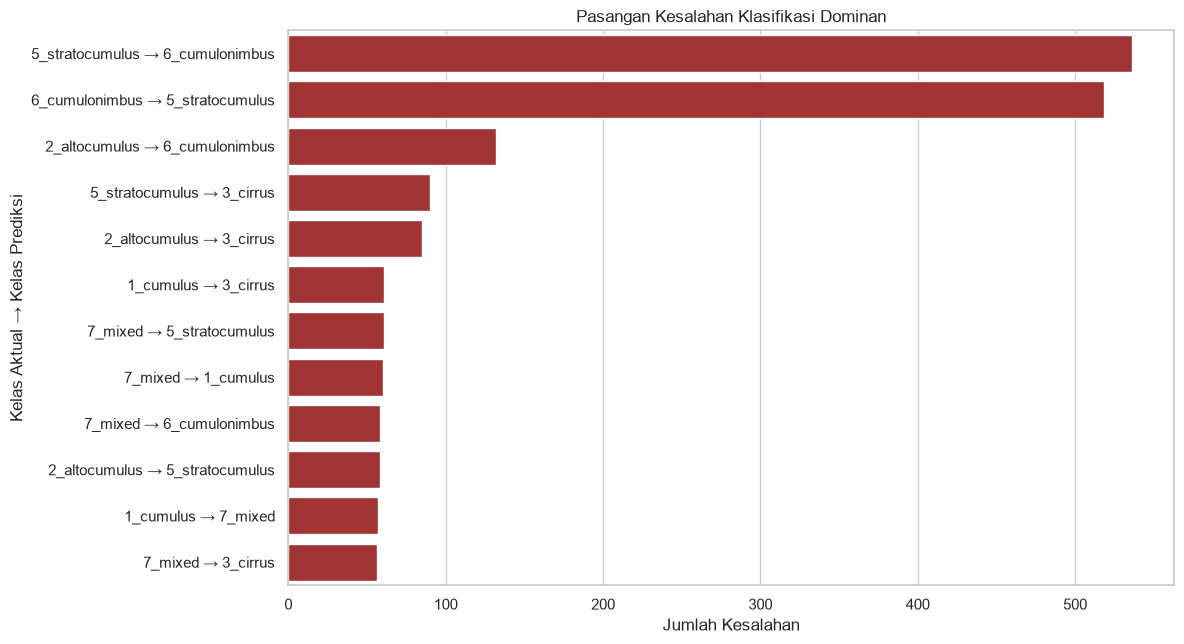

In [69]:
ERROR_PAIR_FIGURE_PATH = (
    FIGURES_DIR
    / "dominant_error_pairs.png"
)


if not error_pairs_df.empty:
    top_error_pairs_plot_df = (
        error_pairs_df
        .head(
            MAX_ERROR_PAIRS_DISPLAY
        )
        .copy()
    )

    top_error_pairs_plot_df[
        "error_pair"
    ] = (
        top_error_pairs_plot_df[
            "true_class"
        ]
        + " → "
        + top_error_pairs_plot_df[
            "predicted_class"
        ]
    )


    plt.figure(
        figsize=(
            12,
            max(
                6,
                0.55
                * len(
                    top_error_pairs_plot_df
                ),
            ),
        )
    )

    sns.barplot(
        data=top_error_pairs_plot_df,
        x="error_count",
        y="error_pair",
        color="firebrick",
    )

    plt.title(
        "Pasangan Kesalahan Klasifikasi Dominan"
    )

    plt.xlabel(
        "Jumlah Kesalahan"
    )

    plt.ylabel(
        "Kelas Aktual → Kelas Prediksi"
    )

    plt.tight_layout()

    plt.savefig(
        ERROR_PAIR_FIGURE_PATH,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

else:
    print(
        "Tidak terdapat kesalahan sehingga grafik "
        "pasangan kesalahan tidak dibuat."
    )

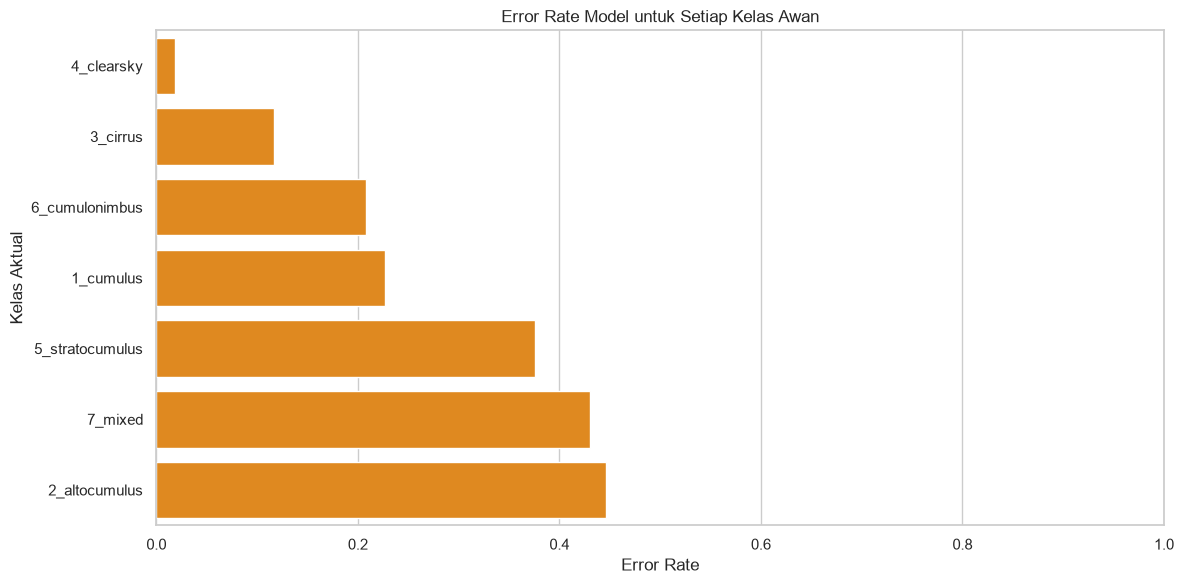

In [70]:
PER_CLASS_ERROR_FIGURE_PATH = (
    FIGURES_DIR
    / "per_class_error_rate.png"
)


per_class_plot_df = (
    per_class_error_df
    .sort_values(
        "error_rate",
        ascending=True,
    )
)


plt.figure(
    figsize=(
        12,
        max(
            6,
            0.55
            * len(
                per_class_plot_df
            ),
        ),
    )
)

sns.barplot(
    data=per_class_plot_df,
    x="error_rate",
    y="class_name",
    color="darkorange",
)

plt.title(
    "Error Rate Model untuk Setiap Kelas Awan"
)

plt.xlabel(
    "Error Rate"
)

plt.ylabel(
    "Kelas Aktual"
)

plt.xlim(
    0.0,
    max(
        1.0,
        float(
            per_class_plot_df[
                "error_rate"
            ].max()
        ) * 1.1,
    ),
)

plt.tight_layout()

plt.savefig(
    PER_CLASS_ERROR_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

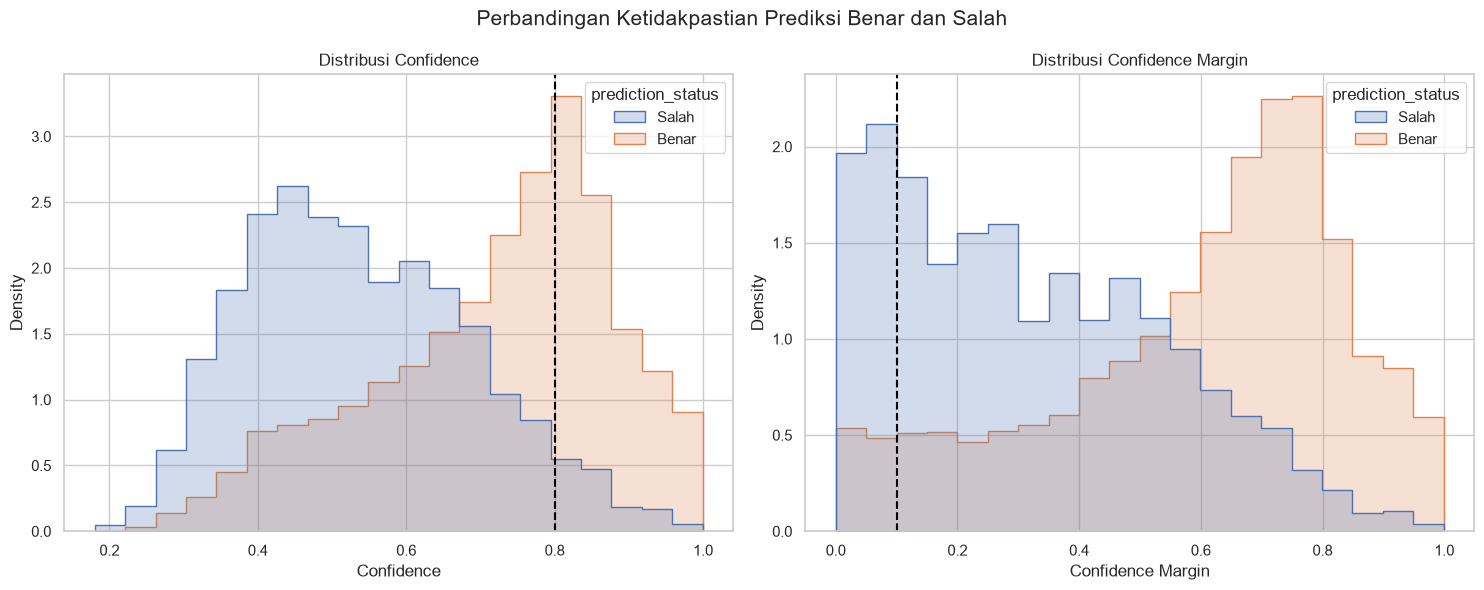

In [71]:
CONFIDENCE_DISTRIBUTION_FIGURE_PATH = (
    FIGURES_DIR
    / "confidence_correct_vs_error.png"
)


confidence_plot_df = (
    predictions_df
    .copy()
)

confidence_plot_df[
    "prediction_status"
] = np.where(
    confidence_plot_df["correct"],
    "Benar",
    "Salah",
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)


sns.histplot(
    data=confidence_plot_df,
    x="confidence",
    hue="prediction_status",
    bins=20,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[0],
)

axes[0].axvline(
    HIGH_CONFIDENCE_THRESHOLD,
    color="black",
    linestyle="--",
    label="Batas confidence tinggi",
)

axes[0].set_title(
    "Distribusi Confidence"
)

axes[0].set_xlabel(
    "Confidence"
)

axes[0].set_ylabel(
    "Density"
)


sns.histplot(
    data=confidence_plot_df,
    x="confidence_margin",
    hue="prediction_status",
    bins=20,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[1],
)

axes[1].axvline(
    LOW_CONFIDENCE_MARGIN,
    color="black",
    linestyle="--",
    label="Batas margin rendah",
)

axes[1].set_title(
    "Distribusi Confidence Margin"
)

axes[1].set_xlabel(
    "Confidence Margin"
)

axes[1].set_ylabel(
    "Density"
)


figure.suptitle(
    "Perbandingan Ketidakpastian Prediksi Benar dan Salah",
    fontsize=15,
)

plt.tight_layout()

plt.savefig(
    CONFIDENCE_DISTRIBUTION_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

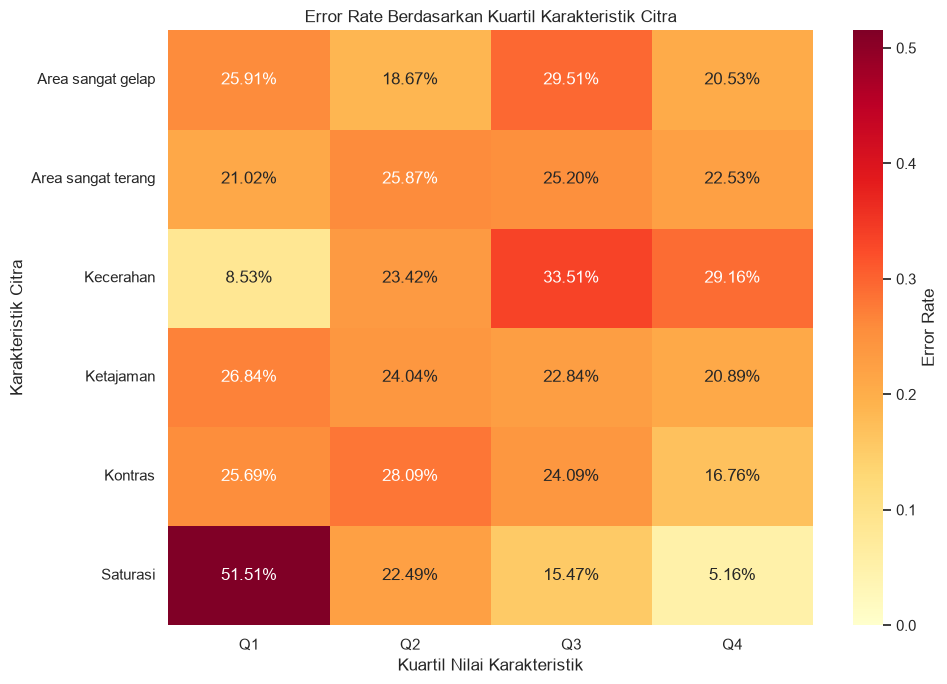

In [72]:
IMAGE_QUALITY_FIGURE_PATH = (
    FIGURES_DIR
    / "image_characteristic_error_rate.png"
)


if not image_quality_profile_df.empty:
    image_quality_pivot_df = (
        image_quality_profile_df
        .pivot(
            index="metric_name",
            columns="quartile",
            values="error_rate",
        )
        .reindex(
            columns=[
                "Q1",
                "Q2",
                "Q3",
                "Q4",
            ]
        )
    )


    plt.figure(
        figsize=(10, 7)
    )

    sns.heatmap(
        image_quality_pivot_df,
        annot=True,
        fmt=".2%",
        cmap="YlOrRd",
        vmin=0.0,
        cbar_kws={
            "label": "Error Rate",
        },
    )

    plt.title(
        "Error Rate Berdasarkan Kuartil Karakteristik Citra"
    )

    plt.xlabel(
        "Kuartil Nilai Karakteristik"
    )

    plt.ylabel(
        "Karakteristik Citra"
    )

    plt.tight_layout()

    plt.savefig(
        IMAGE_QUALITY_FIGURE_PATH,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

else:
    print(
        "Heatmap karakteristik citra tidak dibuat."
    )

In [73]:
image_location_columns = [
    "sample_id",
    "image_path_resolved",
    "resolved_exists",
]


image_location_df = (
    predictions_with_path_df[
        image_location_columns
    ]
    .copy()
)


high_confidence_examples_df = (
    high_confidence_errors_df
    .merge(
        image_location_df,
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
)


ambiguous_error_examples_df = (
    ambiguous_errors_df
    .merge(
        image_location_df,
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
)


if not error_pairs_df.empty:
    dominant_pair_row = (
        error_pairs_df
        .iloc[0]
    )

    dominant_pair_examples_df = (
        errors_df
        .loc[
            (
                errors_df["true_id"]
                == dominant_pair_row["true_id"]
            )
            & (
                errors_df["predicted_id"]
                == dominant_pair_row[
                    "predicted_id"
                ]
            )
        ]
        .sort_values(
            "confidence",
            ascending=False,
        )
        .merge(
            image_location_df,
            on="sample_id",
            how="left",
            validate="one_to_one",
        )
    )

else:
    dominant_pair_row = None

    dominant_pair_examples_df = pd.DataFrame()

In [74]:
def display_prediction_images(
    data: pd.DataFrame,
    title: str,
    output_path: Path,
    maximum_images: int = 12,
    columns: int = 4,
):
    """
    Menampilkan grid contoh hasil prediksi.
    """
    if data.empty:
        print(
            f"Tidak ada data untuk visualisasi: {title}"
        )
        return False


    display_data = (
        data
        .loc[
            data["resolved_exists"]
            .fillna(False)
        ]
        .head(
            maximum_images
        )
        .copy()
    )


    if display_data.empty:
        print(
            "Path citra tidak ditemukan untuk visualisasi: "
            f"{title}"
        )
        return False


    number_of_images = len(
        display_data
    )

    rows = math.ceil(
        number_of_images
        / columns
    )


    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            4 * columns,
            4 * rows,
        ),
    )

    axes = np.asarray(
        axes
    ).reshape(-1)


    for axis in axes:
        axis.axis("off")


    for axis, row in zip(
        axes,
        display_data.itertuples(
            index=False
        ),
    ):
        try:
            with Image.open(
                row.image_path_resolved
            ) as image:
                image = ImageOps.exif_transpose(
                    image
                ).convert("RGB")

                axis.imshow(
                    image
                )

            axis.set_title(
                (
                    f"Aktual: {row.true_class}\n"
                    f"Prediksi: {row.predicted_class}\n"
                    f"Conf: {row.confidence:.3f} | "
                    f"Margin: {row.confidence_margin:.3f}"
                ),
                fontsize=9,
            )

            axis.axis("off")

        except Exception as exc:
            axis.text(
                0.5,
                0.5,
                (
                    "Citra gagal dibaca\n"
                    f"{type(exc).__name__}"
                ),
                ha="center",
                va="center",
            )


    figure.suptitle(
        title,
        fontsize=15,
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()

    return True

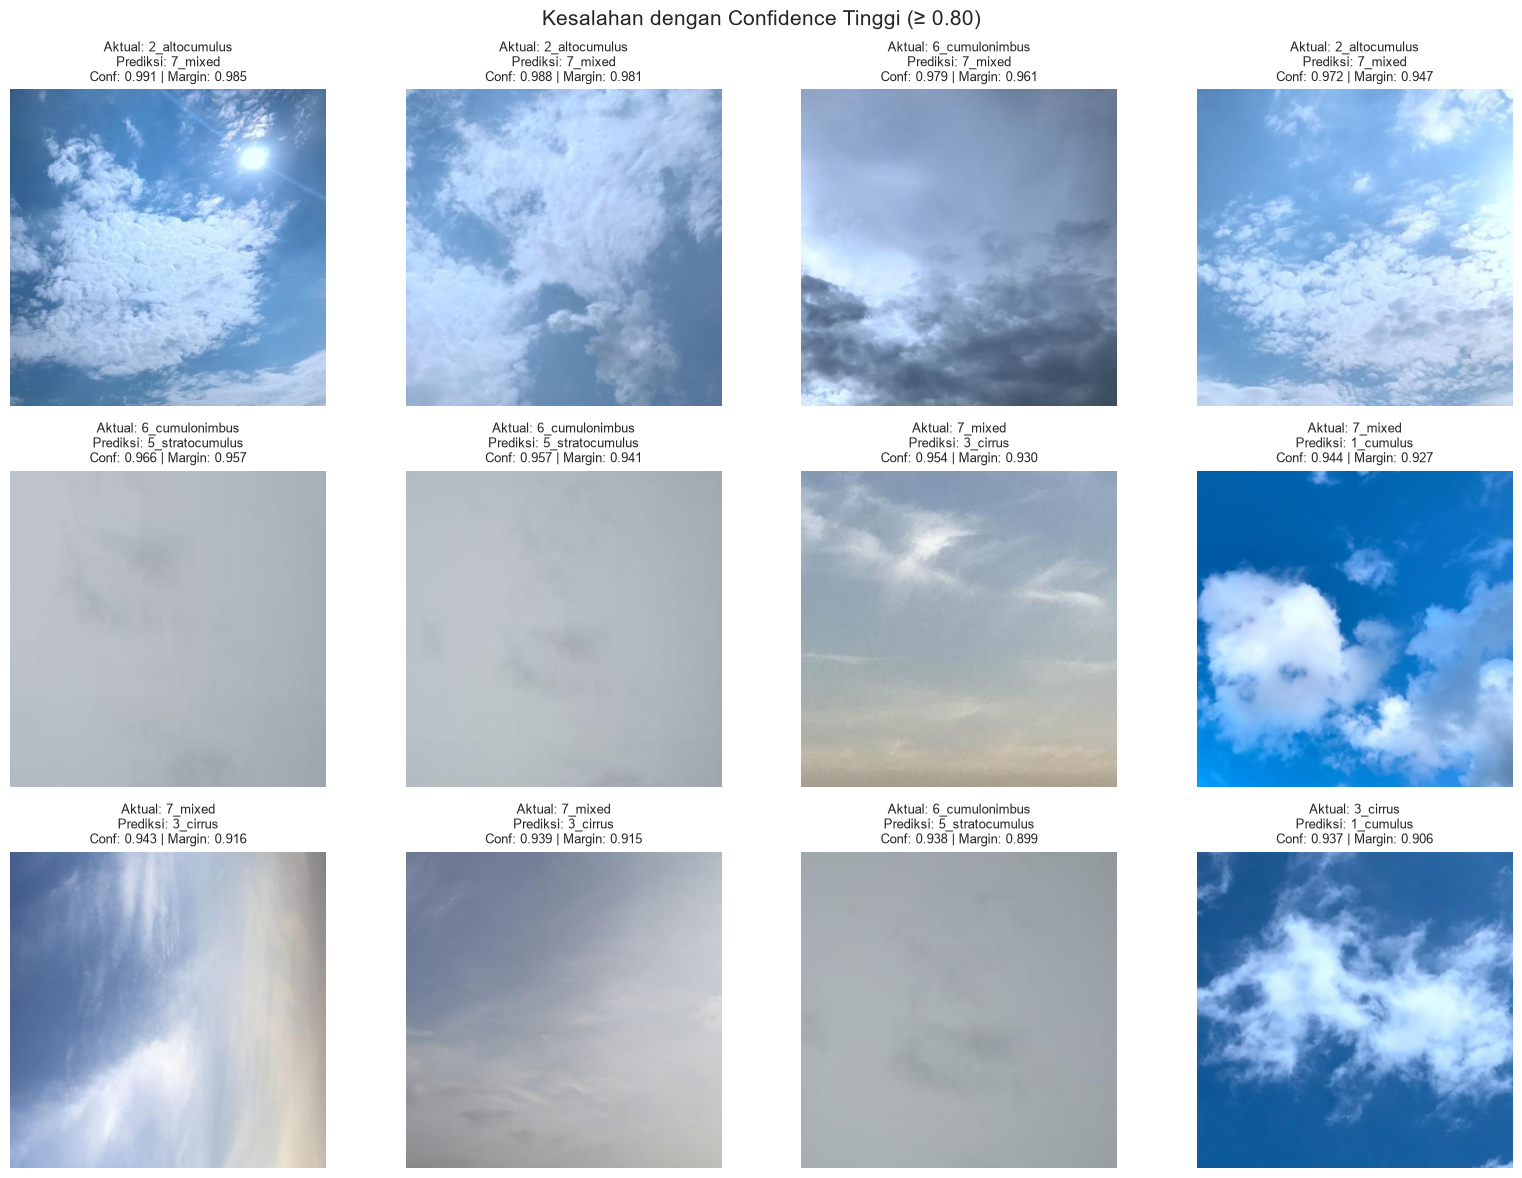

In [75]:
HIGH_CONFIDENCE_ERROR_FIGURE_PATH = (
    FIGURES_DIR
    / "high_confidence_errors.png"
)


high_confidence_figure_created = (
    display_prediction_images(
        data=high_confidence_examples_df,
        title=(
            "Kesalahan dengan Confidence Tinggi "
            f"(≥ {HIGH_CONFIDENCE_THRESHOLD:.2f})"
        ),
        output_path=(
            HIGH_CONFIDENCE_ERROR_FIGURE_PATH
        ),
        maximum_images=MAX_IMAGE_EXAMPLES,
    )
)

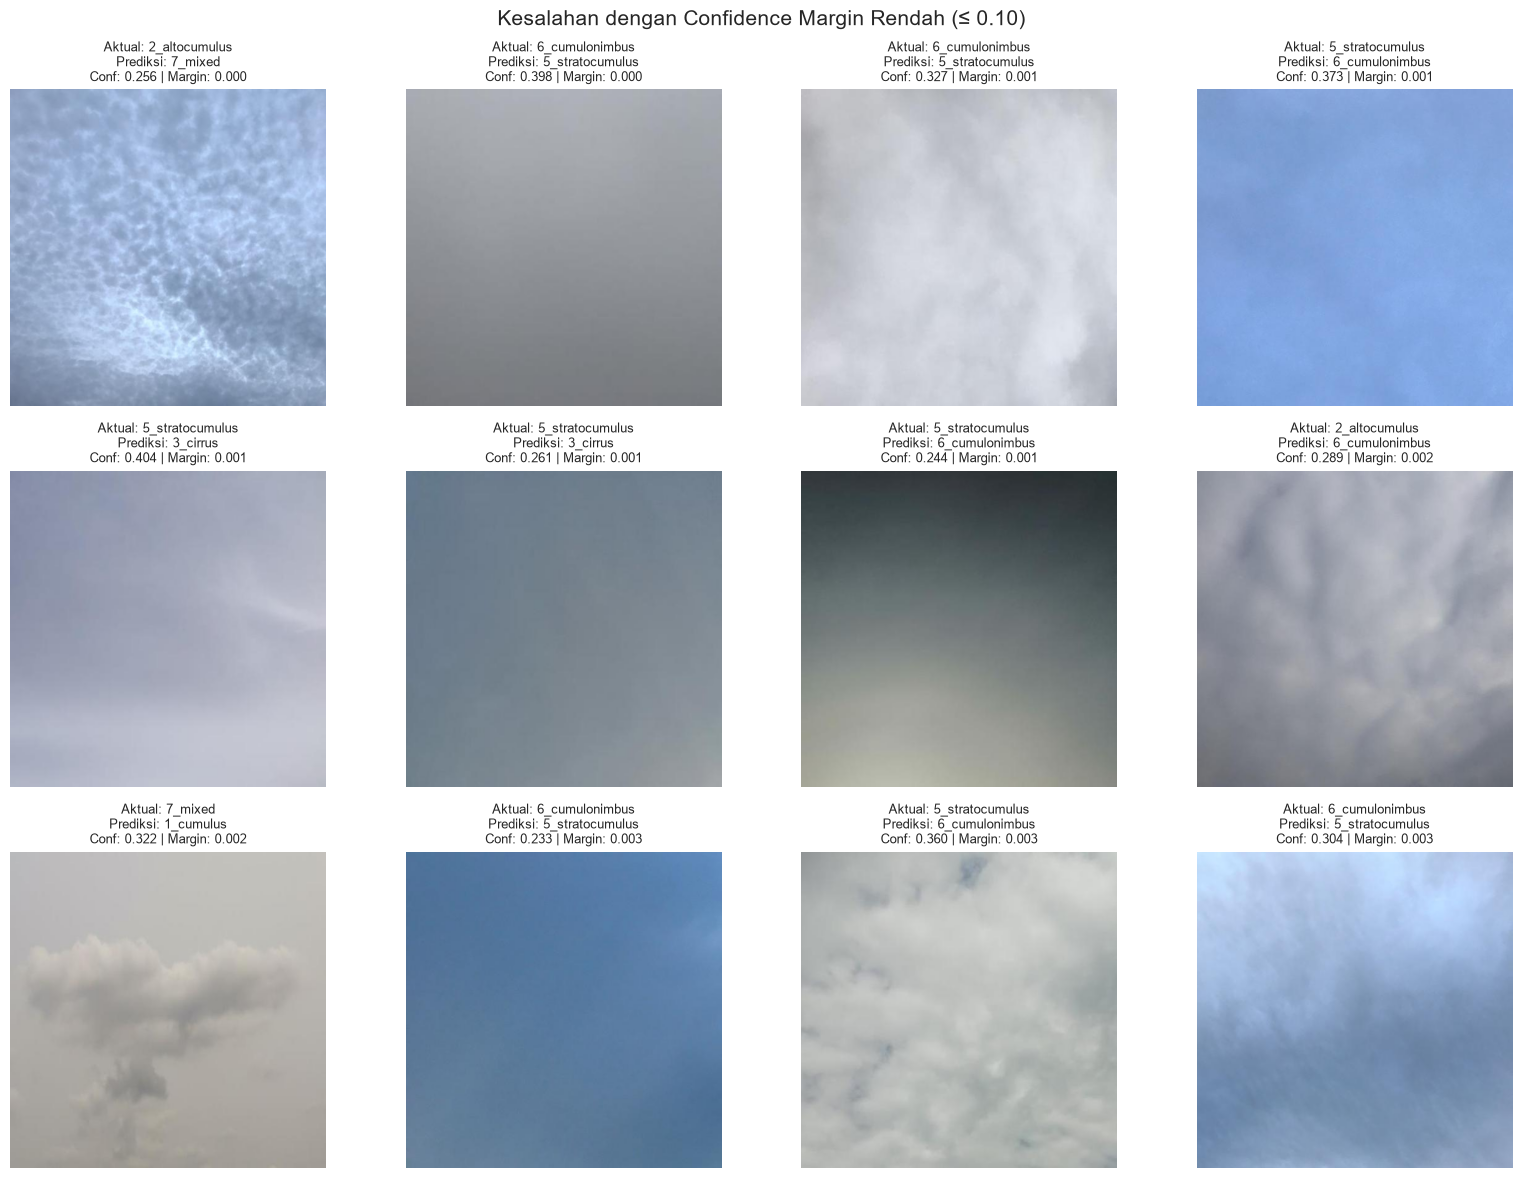

In [76]:
AMBIGUOUS_ERROR_FIGURE_PATH = (
    FIGURES_DIR
    / "ambiguous_errors.png"
)


ambiguous_error_figure_created = (
    display_prediction_images(
        data=ambiguous_error_examples_df,
        title=(
            "Kesalahan dengan Confidence Margin Rendah "
            f"(≤ {LOW_CONFIDENCE_MARGIN:.2f})"
        ),
        output_path=(
            AMBIGUOUS_ERROR_FIGURE_PATH
        ),
        maximum_images=MAX_IMAGE_EXAMPLES,
    )
)

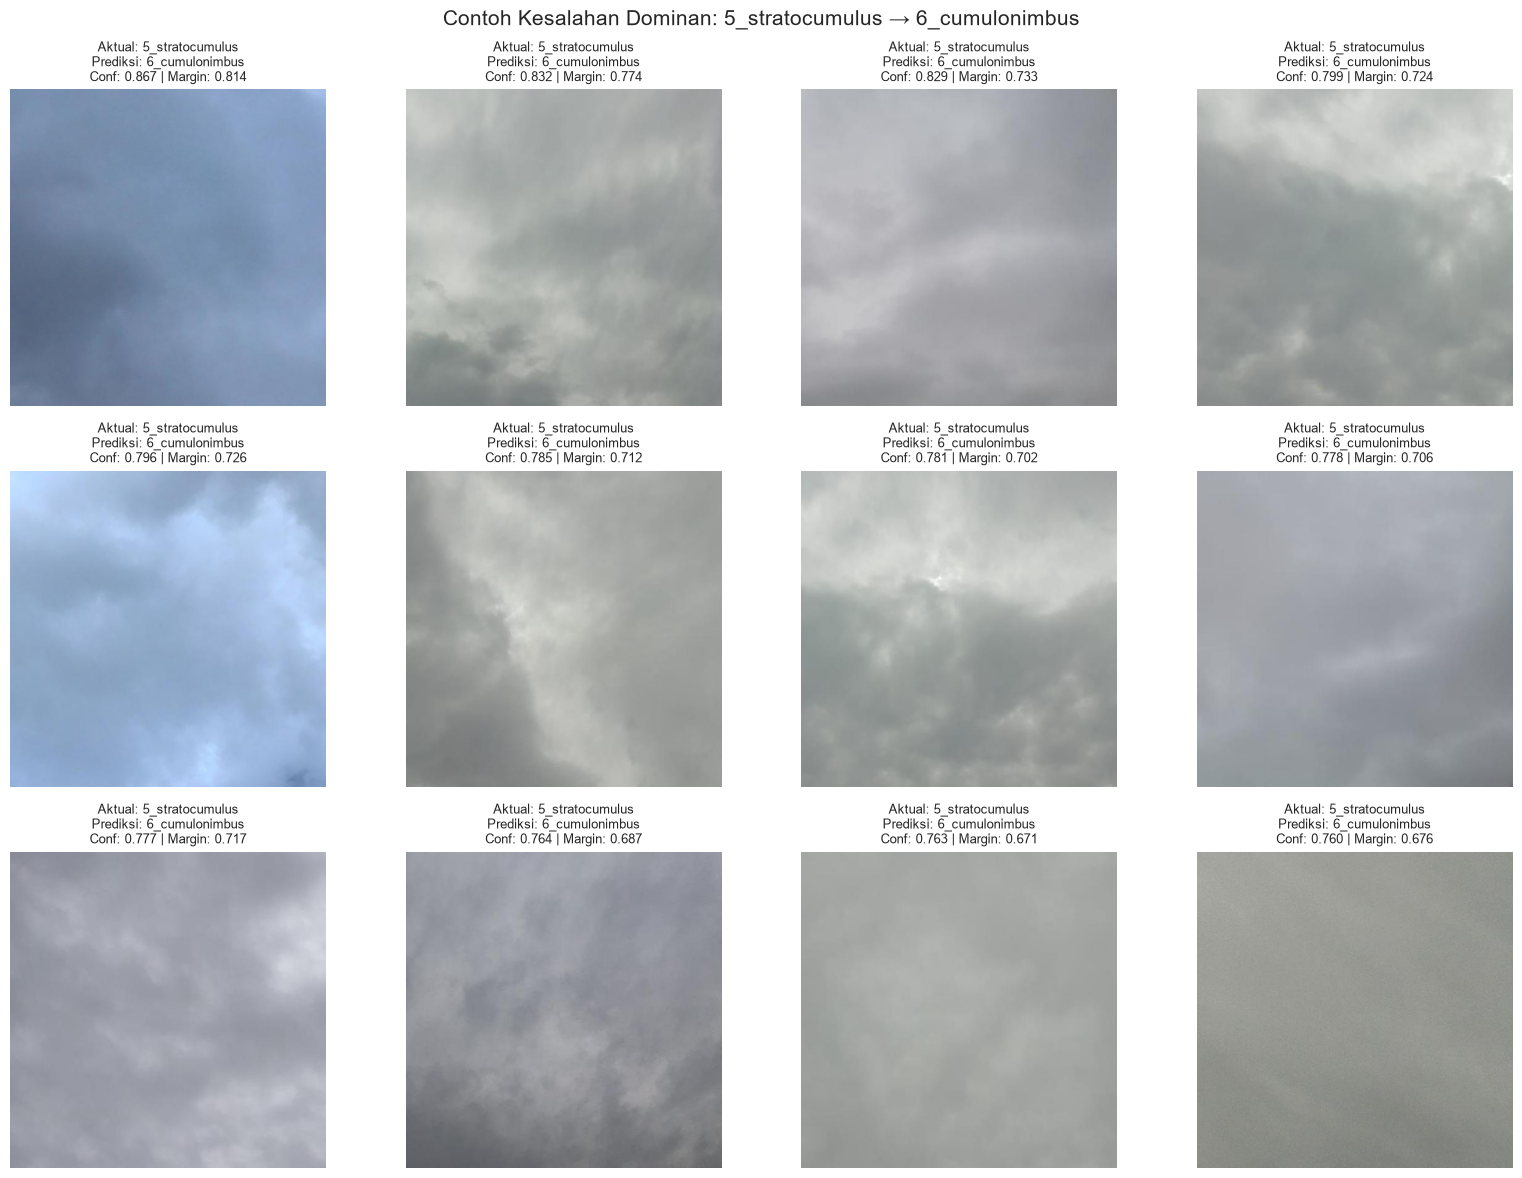

In [77]:
DOMINANT_PAIR_EXAMPLES_FIGURE_PATH = (
    FIGURES_DIR
    / "dominant_error_pair_examples.png"
)


if dominant_pair_row is not None:
    dominant_pair_title = (
        "Contoh Kesalahan Dominan: "
        f"{dominant_pair_row['true_class']} → "
        f"{dominant_pair_row['predicted_class']}"
    )

    dominant_pair_figure_created = (
        display_prediction_images(
            data=dominant_pair_examples_df,
            title=dominant_pair_title,
            output_path=(
                DOMINANT_PAIR_EXAMPLES_FIGURE_PATH
            ),
            maximum_images=MAX_IMAGE_EXAMPLES,
        )
    )

else:
    dominant_pair_figure_created = False

    print(
        "Tidak terdapat pasangan kesalahan dominan."
    )

In [78]:
MISCLASSIFIED_SAMPLES_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "misclassified_samples.csv"
)

ERROR_PAIRS_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "error_pairs_detailed.csv"
)

PER_CLASS_ERROR_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "per_class_error_profile.csv"
)

CONFIDENCE_PROFILE_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "confidence_error_profile.csv"
)

MARGIN_PROFILE_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "confidence_margin_error_profile.csv"
)

HIGH_CONFIDENCE_ERRORS_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "high_confidence_errors.csv"
)

AMBIGUOUS_ERRORS_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "ambiguous_errors.csv"
)

IMAGE_FEATURES_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "image_characteristics.csv"
)

IMAGE_QUALITY_PROFILE_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "image_characteristic_error_profile.csv"
)

ERROR_ANALYSIS_SUMMARY_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "error_analysis_summary.json"
)

ERROR_ANALYSIS_REPORT_PATH = (
    ERROR_ANALYSIS_OUTPUT_DIR
    / "error_analysis_report.md"
)

In [79]:
def make_portable_path(
    path,
):
    """
    Mengubah path absolut menjadi relatif terhadap project jika memungkinkan.
    """
    if path is None or pd.isna(path):
        return None

    path = Path(path)

    try:
        return str(
            path.relative_to(
                PROJECT_DIR
            )
        )

    except ValueError:
        return str(path)


misclassified_export_df = (
    errors_df
    .merge(
        resolved_image_df,
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
)

misclassified_export_df[
    "image_path_resolved"
] = (
    misclassified_export_df[
        "image_path_resolved"
    ]
    .map(make_portable_path)
)


image_features_export_df = (
    image_features_df
    .copy()
)

if not image_features_export_df.empty:
    image_features_export_df[
        "image_path_resolved"
    ] = (
        image_features_export_df[
            "image_path_resolved"
        ]
        .map(make_portable_path)
    )


misclassified_export_df.to_csv(
    MISCLASSIFIED_SAMPLES_PATH,
    index=False,
    encoding="utf-8",
)

error_pairs_df.to_csv(
    ERROR_PAIRS_PATH,
    index=False,
    encoding="utf-8",
)

per_class_error_df.to_csv(
    PER_CLASS_ERROR_PATH,
    index=False,
    encoding="utf-8",
)

confidence_profile_df.to_csv(
    CONFIDENCE_PROFILE_PATH,
    index=False,
    encoding="utf-8",
)

margin_profile_df.to_csv(
    MARGIN_PROFILE_PATH,
    index=False,
    encoding="utf-8",
)

high_confidence_errors_df.to_csv(
    HIGH_CONFIDENCE_ERRORS_PATH,
    index=False,
    encoding="utf-8",
)

ambiguous_errors_df.to_csv(
    AMBIGUOUS_ERRORS_PATH,
    index=False,
    encoding="utf-8",
)

image_features_export_df.to_csv(
    IMAGE_FEATURES_PATH,
    index=False,
    encoding="utf-8",
)

image_quality_profile_df.to_csv(
    IMAGE_QUALITY_PROFILE_PATH,
    index=False,
    encoding="utf-8",
)


print("Seluruh tabel analisis kesalahan berhasil disimpan.")

Seluruh tabel analisis kesalahan berhasil disimpan.


In [80]:
if not error_pairs_df.empty:
    top_error_pair = (
        error_pairs_df
        .iloc[0]
    )

    dominant_error_description = (
        f"{top_error_pair['true_class']} → "
        f"{top_error_pair['predicted_class']} "
        f"sebanyak "
        f"{int(top_error_pair['error_count']):,} citra"
    )

else:
    top_error_pair = None

    dominant_error_description = (
        "Tidak terdapat kesalahan klasifikasi"
    )


highest_error_class = (
    per_class_error_df
    .sort_values(
        [
            "error_rate",
            "error_count",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)


if not high_confidence_errors_df.empty:
    highest_confidence_error = (
        high_confidence_errors_df
        .iloc[0]
    )

    highest_confidence_error_description = (
        f"{highest_confidence_error['true_class']} → "
        f"{highest_confidence_error['predicted_class']} "
        f"dengan confidence "
        f"{highest_confidence_error['confidence']:.4f}"
    )

else:
    highest_confidence_error = None

    highest_confidence_error_description = (
        "Tidak terdapat kesalahan confidence tinggi"
    )


if not image_quality_profile_df.empty:
    highest_quality_error_group = (
        image_quality_profile_df
        .sort_values(
            [
                "error_rate",
                "sample_count",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .iloc[0]
    )

    quality_finding_description = (
        f"{highest_quality_error_group['metric_name']} "
        f"{highest_quality_error_group['quartile']} "
        f"dengan error rate "
        f"{highest_quality_error_group['error_rate']:.2%}"
    )

else:
    highest_quality_error_group = None

    quality_finding_description = (
        "Karakteristik citra tidak dianalisis"
    )


finding_table = pd.DataFrame({
    "Temuan": [
        "Pasangan kesalahan dominan",
        "Kelas dengan error rate tertinggi",
        "Kesalahan dengan confidence tertinggi",
        "Kelompok karakteristik dengan error rate tertinggi",
    ],
    "Hasil": [
        dominant_error_description,
        (
            f"{highest_error_class['class_name']} "
            f"({highest_error_class['error_rate']:.2%})"
        ),
        highest_confidence_error_description,
        quality_finding_description,
    ],
})


display(finding_table)

,Temuan,Hasil
0,Pasangan kesalahan dominan,5_stratocumulus → 6_cumulonimbus sebanyak 536 citra
1,Kelas dengan error rate tertinggi,2_altocumulus (44.67%)
2,Kesalahan dengan confidence tertinggi,2_altocumulus → 7_mixed dengan confidence 0.9914
3,Kelompok karakteristik dengan error rate tertinggi,Saturasi Q1 dengan error rate 51.51%


In [81]:
def json_safe(
    value,
):
    """
    Mengubah objek NumPy, Pandas, Path, dan nilai non-finite
    menjadi nilai yang kompatibel dengan JSON.
    """
    if isinstance(
        value,
        np.generic,
    ):
        value = value.item()

    if isinstance(
        value,
        Path,
    ):
        return str(value)

    if isinstance(
        value,
        dict,
    ):
        return {
            str(key): json_safe(item)
            for key, item
            in value.items()
        }

    if isinstance(
        value,
        (list, tuple),
    ):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(
        value,
        float,
    ) and not np.isfinite(value):
        return None

    if pd.isna(value):
        return None

    return value

In [82]:
error_analysis_summary = {
    "created_at": (
        datetime.now()
        .astimezone()
        .isoformat(timespec="seconds")
    ),

    "stage": "12_analisis_kesalahan",

    "analysis_run_id": (
        ERROR_ANALYSIS_RUN_ID
    ),

    "analysis_design": {
        "source": "saved_test_predictions",
        "model_loaded": False,
        "model_inference_performed": False,
        "model_weights_updated": False,
        "training_performed": False,
        "test_used_for_model_selection": False,
        "test_used_for_hyperparameter_tuning": False,
    },

    "model": {
        "model_name": MODEL_NAME,
        "num_classes": NUM_CLASSES,
        "class_to_idx": CLASS_TO_IDX,
        "input_shape": model_config[
            "input_shape"
        ],
    },

    "selected_runs": {
        "evaluation": str(
            EVALUATION_RUN_DIR.relative_to(
                PROJECT_DIR
            )
        ),
        "test": str(
            TEST_RUN_DIR.relative_to(
                PROJECT_DIR
            )
        ),
    },

    "thresholds": {
        "high_confidence": (
            HIGH_CONFIDENCE_THRESHOLD
        ),
        "low_confidence_margin": (
            LOW_CONFIDENCE_MARGIN
        ),
    },

    "overall": {
        "number_of_samples": TOTAL_SAMPLES,
        "number_of_correct_predictions": (
            TOTAL_CORRECT
        ),
        "number_of_errors": TOTAL_ERRORS,
        "accuracy": calculated_accuracy,
        "error_rate": ERROR_RATE,
    },

    "confidence_findings": {
        "high_confidence_error_count": int(
            len(
                high_confidence_errors_df
            )
        ),
        "ambiguous_error_count": int(
            len(
                ambiguous_errors_df
            )
        ),
        "highest_confidence_error": (
            None
            if highest_confidence_error is None
            else highest_confidence_error[
                [
                    "sample_id",
                    "true_class",
                    "predicted_class",
                    "confidence",
                    "confidence_margin",
                    "image_path",
                ]
            ].to_dict()
        ),
    },

    "dominant_error_pair": (
        None
        if top_error_pair is None
        else top_error_pair.to_dict()
    ),

    "highest_error_class": (
        highest_error_class.to_dict()
    ),

    "image_analysis": {
        "enabled": (
            ANALYZE_IMAGE_CHARACTERISTICS
        ),
        "successfully_analyzed_images": (
            successful_image_features
        ),
        "highest_error_characteristic_group": (
            None
            if highest_quality_error_group is None
            else highest_quality_error_group.to_dict()
        ),
    },

    "input_artifact_sha256": (
        SOURCE_HASHES_BEFORE
    ),

    "output_artifacts": {
        "misclassified_samples": str(
            MISCLASSIFIED_SAMPLES_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "error_pairs": str(
            ERROR_PAIRS_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "per_class_error_profile": str(
            PER_CLASS_ERROR_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "confidence_profile": str(
            CONFIDENCE_PROFILE_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "confidence_margin_profile": str(
            MARGIN_PROFILE_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "high_confidence_errors": str(
            HIGH_CONFIDENCE_ERRORS_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "ambiguous_errors": str(
            AMBIGUOUS_ERRORS_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "image_characteristics": str(
            IMAGE_FEATURES_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "image_characteristic_error_profile": str(
            IMAGE_QUALITY_PROFILE_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },
}


with ERROR_ANALYSIS_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        json_safe(
            error_analysis_summary
        ),
        file,
        ensure_ascii=False,
        indent=2,
    )


print(
    "Ringkasan JSON disimpan:\n"
    f"{ERROR_ANALYSIS_SUMMARY_PATH.relative_to(PROJECT_DIR)}"
)

Ringkasan JSON disimpan:
logs\resnet50_error_analysis_20260827_085019_649543\error_analysis_summary.json


In [83]:
high_confidence_error_rate = (
    len(high_confidence_errors_df)
    / TOTAL_ERRORS
    if TOTAL_ERRORS > 0
    else 0.0
)

ambiguous_error_rate = (
    len(ambiguous_errors_df)
    / TOTAL_ERRORS
    if TOTAL_ERRORS > 0
    else 0.0
)


error_analysis_report = f"""# Laporan Analisis Kesalahan Model

## Identitas Analisis

- Model: `{MODEL_NAME}`
- Jumlah kelas: {NUM_CLASSES}
- Run evaluasi: `{EVALUATION_RUN_DIR.relative_to(PROJECT_DIR)}`
- Run pengujian: `{TEST_RUN_DIR.relative_to(PROJECT_DIR)}`
- Jumlah sampel test: {TOTAL_SAMPLES:,}

## Ringkasan Kesalahan

- Prediksi benar: {TOTAL_CORRECT:,}
- Prediksi salah: {TOTAL_ERRORS:,}
- Accuracy: {calculated_accuracy:.4%}
- Error rate: {ERROR_RATE:.4%}

## Kesalahan Dominan

- Pasangan kesalahan dominan: {dominant_error_description}
- Kelas dengan error rate tertinggi: `{highest_error_class["class_name"]}`
- Error rate kelas tersebut: {highest_error_class["error_rate"]:.4%}
- Jumlah kesalahan kelas tersebut: {int(highest_error_class["error_count"]):,}

## Confidence Kesalahan

- Batas confidence tinggi: {HIGH_CONFIDENCE_THRESHOLD:.2f}
- Jumlah kesalahan confidence tinggi: {len(high_confidence_errors_df):,}
- Proporsi terhadap seluruh kesalahan: {high_confidence_error_rate:.4%}
- Batas confidence margin rendah: {LOW_CONFIDENCE_MARGIN:.2f}
- Jumlah kesalahan ambigu: {len(ambiguous_errors_df):,}
- Proporsi kesalahan ambigu: {ambiguous_error_rate:.4%}
- Kesalahan dengan confidence tertinggi: {highest_confidence_error_description}

## Karakteristik Citra

- Analisis karakteristik citra diaktifkan: {ANALYZE_IMAGE_CHARACTERISTICS}
- Citra yang berhasil dianalisis: {successful_image_features:,}
- Kelompok dengan error rate tertinggi: {quality_finding_description}

## Interpretasi

Pasangan kesalahan dominan menunjukkan kelas awan yang paling sering tertukar.
Kesalahan dengan confidence tinggi perlu diperiksa secara manual karena model
memberikan keyakinan tinggi pada kelas yang tidak sesuai dengan label aktual.

Kesalahan dengan confidence margin rendah mengindikasikan kemiripan skor antara
kelas prediksi pertama dan kelas alternatif. Kondisi tersebut dapat berkaitan
dengan kemiripan visual antarjenis awan, kualitas citra, objek pengganggu,
komposisi awan campuran, atau ketidakjelasan label.

Karakteristik kecerahan, kontras, saturasi, dan ketajaman hanya memberikan
indikasi deskriptif. Hasil tersebut tidak membuktikan bahwa suatu karakteristik
menjadi penyebab langsung kesalahan model.

## Batasan Metodologis

Analisis menggunakan test split yang sebelumnya telah digunakan satu kali untuk
evaluasi akhir. Temuan dari test split tidak boleh digunakan untuk menyesuaikan
hyperparameter atau memilih checkpoint. Jika diperlukan perbaikan model, pola
kesalahan harus dikonfirmasi kembali menggunakan data train dan validation atau
dataset eksternal yang independen.

Model tidak dimuat, inference tidak diulang, training tidak dilakukan, dan bobot
model tidak diperbarui dalam notebook ini.
"""


ERROR_ANALYSIS_REPORT_PATH.write_text(
    error_analysis_report,
    encoding="utf-8",
)


print(error_analysis_report)

# Laporan Analisis Kesalahan Model

## Identitas Analisis

- Model: `resnet50`
- Jumlah kelas: 7
- Run evaluasi: `logs\resnet50_evaluation_20260826_233246_842963`
- Run pengujian: `logs\resnet50_final_test_20260826_232648`
- Jumlah sampel test: 9,000

## Ringkasan Kesalahan

- Prediksi benar: 6,871
- Prediksi salah: 2,129
- Accuracy: 76.3444%
- Error rate: 23.6556%

## Kesalahan Dominan

- Pasangan kesalahan dominan: 5_stratocumulus → 6_cumulonimbus sebanyak 536 citra
- Kelas dengan error rate tertinggi: `2_altocumulus`
- Error rate kelas tersebut: 44.6667%
- Jumlah kesalahan kelas tersebut: 335

## Confidence Kesalahan

- Batas confidence tinggi: 0.80
- Jumlah kesalahan confidence tinggi: 117
- Proporsi terhadap seluruh kesalahan: 5.4955%
- Batas confidence margin rendah: 0.10
- Jumlah kesalahan ambigu: 434
- Proporsi kesalahan ambigu: 20.3852%
- Kesalahan dengan confidence tertinggi: 2_altocumulus → 7_mixed dengan confidence 0.9914

## Karakteristik Citra

- Analisis karakteristik ci

In [84]:
SOURCE_HASHES_AFTER = {
    artifact_name: calculate_sha256(path)
    for artifact_name, path
    in SOURCE_ARTIFACTS.items()
}


source_integrity_df = pd.DataFrame({
    "Artefak": SOURCE_HASHES_BEFORE.keys(),
    "Hash sebelum": SOURCE_HASHES_BEFORE.values(),
    "Hash setelah": SOURCE_HASHES_AFTER.values(),
})


source_integrity_df["Tidak berubah"] = (
    source_integrity_df["Hash sebelum"]
    == source_integrity_df["Hash setelah"]
)


display(source_integrity_df)


if not source_integrity_df[
    "Tidak berubah"
].all():
    changed_artifacts = (
        source_integrity_df
        .loc[
            ~source_integrity_df[
                "Tidak berubah"
            ],
            "Artefak",
        ]
        .tolist()
    )

    raise RuntimeError(
        "Artefak sumber berubah selama analisis: "
        f"{changed_artifacts}"
    )


print("Seluruh artefak sumber tetap tidak berubah.")

,Artefak,Hash sebelum,Hash setelah,Tidak berubah
0,model_config,2b907a24e7cddc0941805376a8ec64b1ff556d5e830fb5df09f6a3e11e9f6e50,2b907a24e7cddc0941805376a8ec64b1ff556d5e830fb5df09f6a3e11e9f6e50,True
1,evaluation_summary,7bb60f853452504cd0b12c371ce09201147ed2df08f3ea52edb054a7b4567e8c,7bb60f853452504cd0b12c371ce09201147ed2df08f3ea52edb054a7b4567e8c,True
2,test_predictions,45eea5093d840146cafa028ec4a1415ff05add35dd1e82f93d4a7a72be700b09,45eea5093d840146cafa028ec4a1415ff05add35dd1e82f93d4a7a72be700b09,True
3,test_metrics,3b52e6beada2b05fc34f50c2c379ada9c53cedcba767ff8a8230c6f9ef50e137,3b52e6beada2b05fc34f50c2c379ada9c53cedcba767ff8a8230c6f9ef50e137,True
4,test_per_class,9d2c98fbcff98093f4cbd7e7dad60813d7105af006a76651125cceb1d2a529d0,9d2c98fbcff98093f4cbd7e7dad60813d7105af006a76651125cceb1d2a529d0,True
5,test_error_pairs,d01015c65faf7f5b138e8081ebe99f59b0791628391144c6f2736b30dc59addf,d01015c65faf7f5b138e8081ebe99f59b0791628391144c6f2736b30dc59addf,True


Seluruh artefak sumber tetap tidak berubah.


In [85]:
required_output_files = [
    MISCLASSIFIED_SAMPLES_PATH,
    ERROR_PAIRS_PATH,
    PER_CLASS_ERROR_PATH,
    CONFIDENCE_PROFILE_PATH,
    MARGIN_PROFILE_PATH,
    HIGH_CONFIDENCE_ERRORS_PATH,
    AMBIGUOUS_ERRORS_PATH,
    IMAGE_FEATURES_PATH,
    IMAGE_QUALITY_PROFILE_PATH,
    ERROR_ANALYSIS_SUMMARY_PATH,
    ERROR_ANALYSIS_REPORT_PATH,
    PER_CLASS_ERROR_FIGURE_PATH,
    CONFIDENCE_DISTRIBUTION_FIGURE_PATH,
]


if TOTAL_ERRORS > 0:
    required_output_files.append(
        ERROR_PAIR_FIGURE_PATH
    )


optional_created_figures = [
    (
        high_confidence_figure_created,
        HIGH_CONFIDENCE_ERROR_FIGURE_PATH,
    ),
    (
        ambiguous_error_figure_created,
        AMBIGUOUS_ERROR_FIGURE_PATH,
    ),
    (
        dominant_pair_figure_created,
        DOMINANT_PAIR_EXAMPLES_FIGURE_PATH,
    ),
]


for created, path in optional_created_figures:
    if created:
        required_output_files.append(
            path
        )


if not image_quality_profile_df.empty:
    required_output_files.append(
        IMAGE_QUALITY_FIGURE_PATH
    )


pair_error_total = int(
    error_pairs_df[
        "error_count"
    ].sum()
) if not error_pairs_df.empty else 0


final_checks = {
    "Seluruh prediksi dianalisis": (
        len(predictions_df)
        == TOTAL_SAMPLES
    ),

    "Prediksi benar dan salah saling melengkapi": (
        TOTAL_CORRECT
        + TOTAL_ERRORS
        == TOTAL_SAMPLES
    ),

    "Jumlah pasangan kesalahan konsisten": (
        pair_error_total
        == TOTAL_ERRORS
    ),

    "Jumlah support seluruh kelas konsisten": (
        int(
            per_class_error_df[
                "support"
            ].sum()
        )
        == TOTAL_SAMPLES
    ),

    "Jumlah kesalahan per kelas konsisten": (
        int(
            per_class_error_df[
                "error_count"
            ].sum()
        )
        == TOTAL_ERRORS
    ),

    "Artefak sumber tidak berubah": (
        source_integrity_df[
            "Tidak berubah"
        ].all()
    ),

    "Seluruh output wajib tersedia": all(
        path.is_file()
        for path in required_output_files
    ),

    "Inference model dijalankan": False,

    "Training model dilakukan": False,

    "Bobot model diperbarui": False,
}


final_check_df = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),
    "Nilai": final_checks.values(),
    "Status": [
        (
            "Sesuai"
            if (
                check_name
                in {
                    "Inference model dijalankan",
                    "Training model dilakukan",
                    "Bobot model diperbarui",
                }
                and value is False
            )
            else (
                "Berhasil"
                if value
                else "Gagal"
            )
        )
        for check_name, value
        in final_checks.items()
    ],
})


display(final_check_df)


failed_final_checks = [
    check_name
    for check_name, status
    in final_checks.items()
    if (
        check_name
        not in {
            "Inference model dijalankan",
            "Training model dilakukan",
            "Bobot model diperbarui",
        }
        and not status
    )
]


if failed_final_checks:
    raise RuntimeError(
        "Pemeriksaan akhir gagal:\n- "
        + "\n- ".join(
            failed_final_checks
        )
    )


print("Seluruh pemeriksaan akhir berhasil.")

,Pemeriksaan,Nilai,Status
0,Seluruh prediksi dianalisis,True,Berhasil
1,Prediksi benar dan salah saling melengkapi,True,Berhasil
2,Jumlah pasangan kesalahan konsisten,True,Berhasil
3,Jumlah support seluruh kelas konsisten,True,Berhasil
4,Jumlah kesalahan per kelas konsisten,True,Berhasil
5,Artefak sumber tidak berubah,True,Berhasil
6,Seluruh output wajib tersedia,True,Berhasil
7,Inference model dijalankan,False,Sesuai
8,Training model dilakukan,False,Sesuai
9,Bobot model diperbarui,False,Sesuai


Seluruh pemeriksaan akhir berhasil.


In [86]:
print("=" * 78)
print("ANALISIS KESALAHAN MODEL SELESAI")
print("=" * 78)

print(
    f"Model                       : "
    f"{MODEL_NAME}"
)

print(
    f"Jumlah sampel test          : "
    f"{TOTAL_SAMPLES:,}"
)

print(
    f"Prediksi benar              : "
    f"{TOTAL_CORRECT:,}"
)

print(
    f"Prediksi salah              : "
    f"{TOTAL_ERRORS:,}"
)

print(
    f"Accuracy                    : "
    f"{calculated_accuracy:.4%}"
)

print(
    f"Error rate                  : "
    f"{ERROR_RATE:.4%}"
)

print(
    f"Kesalahan dominan           : "
    f"{dominant_error_description}"
)

print(
    f"Kelas error rate tertinggi  : "
    f"{highest_error_class['class_name']} "
    f"({highest_error_class['error_rate']:.4%})"
)

print(
    f"Kesalahan confidence tinggi : "
    f"{len(high_confidence_errors_df):,}"
)

print(
    f"Kesalahan ambigu            : "
    f"{len(ambiguous_errors_df):,}"
)

print(
    f"Citra berhasil dianalisis   : "
    f"{successful_image_features:,}"
)

print(
    f"Folder hasil                : "
    f"{ERROR_ANALYSIS_OUTPUT_DIR.relative_to(PROJECT_DIR)}"
)

print(
    "Inference diulang           : Tidak"
)

print(
    "Training dilakukan          : Tidak"
)

print(
    "Bobot model diperbarui      : Tidak"
)

print("=" * 78)

ANALISIS KESALAHAN MODEL SELESAI
Model                       : resnet50
Jumlah sampel test          : 9,000
Prediksi benar              : 6,871
Prediksi salah              : 2,129
Accuracy                    : 76.3444%
Error rate                  : 23.6556%
Kesalahan dominan           : 5_stratocumulus → 6_cumulonimbus sebanyak 536 citra
Kelas error rate tertinggi  : 2_altocumulus (44.6667%)
Kesalahan confidence tinggi : 117
Kesalahan ambigu            : 434
Citra berhasil dianalisis   : 9,000
Folder hasil                : logs\resnet50_error_analysis_20260827_085019_649543
Inference diulang           : Tidak
Training dilakukan          : Tidak
Bobot model diperbarui      : Tidak


In [87]:
output_artifact_paths = [
    MISCLASSIFIED_SAMPLES_PATH,
    ERROR_PAIRS_PATH,
    PER_CLASS_ERROR_PATH,
    CONFIDENCE_PROFILE_PATH,
    MARGIN_PROFILE_PATH,
    HIGH_CONFIDENCE_ERRORS_PATH,
    AMBIGUOUS_ERRORS_PATH,
    IMAGE_FEATURES_PATH,
    IMAGE_QUALITY_PROFILE_PATH,
    ERROR_ANALYSIS_SUMMARY_PATH,
    ERROR_ANALYSIS_REPORT_PATH,
    ERROR_PAIR_FIGURE_PATH,
    PER_CLASS_ERROR_FIGURE_PATH,
    CONFIDENCE_DISTRIBUTION_FIGURE_PATH,
    IMAGE_QUALITY_FIGURE_PATH,
    HIGH_CONFIDENCE_ERROR_FIGURE_PATH,
    AMBIGUOUS_ERROR_FIGURE_PATH,
    DOMINANT_PAIR_EXAMPLES_FIGURE_PATH,
]


output_artifact_df = pd.DataFrame({
    "Artefak": [
        path.name
        for path in output_artifact_paths
    ],
    "Path": [
        (
            str(
                path.relative_to(
                    PROJECT_DIR
                )
            )
            if path.exists()
            else None
        )
        for path in output_artifact_paths
    ],
    "Ada": [
        path.is_file()
        for path in output_artifact_paths
    ],
})


display(
    output_artifact_df
)

,Artefak,Path,Ada
0,misclassified_samples.csv,logs\resnet50_error_analysis_20260827_085019_649543\misclassified_samples.csv,True
1,error_pairs_detailed.csv,logs\resnet50_error_analysis_20260827_085019_649543\error_pairs_detailed.csv,True
2,per_class_error_profile.csv,logs\resnet50_error_analysis_20260827_085019_649543\per_class_error_profile.csv,True
3,confidence_error_profile.csv,logs\resnet50_error_analysis_20260827_085019_649543\confidence_error_profile.csv,True
4,confidence_margin_error_profile.csv,logs\resnet50_error_analysis_20260827_085019_649543\confidence_margin_error_profile.csv,True
5,high_confidence_errors.csv,logs\resnet50_error_analysis_20260827_085019_649543\high_confidence_errors.csv,True
6,ambiguous_errors.csv,logs\resnet50_error_analysis_20260827_085019_649543\ambiguous_errors.csv,True
7,image_characteristics.csv,logs\resnet50_error_analysis_20260827_085019_649543\image_characteristics.csv,True
8,image_characteristic_error_profile.csv,logs\resnet50_error_analysis_20260827_085019_649543\image_characteristic_error_profile.csv,True
9,error_analysis_summary.json,logs\resnet50_error_analysis_20260827_085019_649543\error_analysis_summary.json,True


## Interpretasi Analisis Kesalahan

### 1. Pasangan kelas yang tertukar

Pasangan kesalahan menunjukkan hubungan antara kelas aktual dan kelas hasil
prediksi. Pasangan dengan jumlah kesalahan tertinggi perlu diperiksa untuk
mengetahui apakah kedua kelas memiliki bentuk, tekstur, ketebalan, atau kondisi
pencahayaan yang serupa.

### 2. Error rate setiap kelas

Kelas dengan error rate tinggi menunjukkan bahwa proporsi citra kelas tersebut
yang berhasil dikenali masih rendah. Error rate perlu dibaca bersama support
kelas karena kelas dengan jumlah data kecil dapat menghasilkan nilai yang lebih
tidak stabil.

### 3. Kesalahan confidence tinggi

Kesalahan confidence tinggi menunjukkan model yakin terhadap prediksi yang
keliru. Citra tersebut menjadi prioritas pemeriksaan manual karena dapat
mengindikasikan:

- kemiripan visual antarjenis awan;
- label yang ambigu;
- citra berisi lebih dari satu tipe awan;
- dominasi langit atau objek bukan awan;
- kualitas citra yang kurang baik;
- perbedaan karakteristik antara data train dan test.

### 4. Kesalahan dengan margin rendah

Confidence margin rendah menunjukkan perbedaan skor kelas pertama dan kelas
alternatif relatif kecil. Model kemungkinan kesulitan membedakan dua kelas yang
memiliki karakteristik visual berdekatan.

### 5. Karakteristik citra

Perbedaan error rate pada kuartil kecerahan, kontras, saturasi, atau ketajaman
dapat membantu menemukan kondisi citra yang sulit dikenali. Namun, hasil ini
merupakan asosiasi deskriptif dan bukan bukti kausal.

### 6. Penggunaan hasil

Temuan pada test split digunakan untuk pelaporan dan diagnosis akhir. Jika model
akan dikembangkan kembali, strategi perbaikan harus diterapkan pada train split
dan dinilai menggunakan validation split, bukan dengan melakukan tuning terhadap
test split.

## Visualisasi Kesalahan Model Menggunakan Grad-CAM

Confusion matrix dan classification report menunjukkan jenis kesalahan
klasifikasi, tetapi belum menjelaskan bagian citra yang memengaruhi
keputusan model. Oleh karena itu, analisis kesalahan dilengkapi dengan
Gradient-weighted Class Activation Mapping (Grad-CAM).

Grad-CAM menghasilkan heatmap berdasarkan gradien skor kelas terhadap
feature map pada lapisan konvolusi terakhir. Pada penelitian ini, Grad-CAM
diterapkan pada `layer4[-1]` ResNet50 karena lapisan tersebut memuat
representasi visual tingkat tinggi sebelum global average pooling dan
classifier.

Untuk setiap citra yang salah diklasifikasikan, visualisasi dibuat terhadap:

1. kelas hasil prediksi model; dan
2. kelas sebenarnya.

Perbandingan keduanya digunakan untuk menilai apakah kesalahan disebabkan
oleh kemiripan visual antarkelas, perhatian pada latar belakang, area citra
yang tidak relevan, pemotongan citra, atau representasi fitur yang kurang
diskriminatif.

Grad-CAM merupakan alat interpretasi, bukan ukuran kuantitatif performa.
Kesimpulan tetap harus dikombinasikan dengan confusion matrix, nilai
confidence, distribusi kelas, dan pemeriksaan citra secara langsung.

In [88]:
from __future__ import annotations

import re
import warnings
from collections.abc import Mapping
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn.functional as F

from PIL import Image
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from timm.data import create_transform, resolve_data_config


# ============================================================
# MENENTUKAN LOKASI PROJECT SECARA DINAMIS
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATASET_DIR = PROJECT_DIR / "dataset"
SOURCE_DIR = DATASET_DIR / "source"
MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

TEST_DIR = SOURCE_DIR / "test"

CHECKPOINT_PATH = (
    MODELS_DIR
    / "releases"
    / "resnet50_gcd_v1.0.0"
    / "resnet50_gcd_final.pth"
)


# ============================================================
# KONFIGURASI GRAD-CAM
# ============================================================

MODEL_NAME = "resnet50"
INPUT_CHANNELS = 3
DROPOUT_RATE = 0.0

BATCH_SIZE = 32
NUM_WORKERS = 0     # Aman untuk Jupyter/VS Code pada Windows
N_GRADCAM = 8       # Jumlah kesalahan dengan confidence tertinggi
OVERLAY_ALPHA = 0.45

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# True hanya karena checkpoint ini dibuat sendiri dalam project.
# Jangan gunakan weights_only=False pada checkpoint dari sumber
# yang tidak dipercaya.
TRUSTED_LOCAL_CHECKPOINT = True


# ============================================================
# VALIDASI PATH
# ============================================================

if not TEST_DIR.exists():
    raise FileNotFoundError(
        f"Folder test tidak ditemukan: {TEST_DIR}"
    )

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "Checkpoint final tidak ditemukan.\n"
        f"Lokasi yang diperiksa: {CHECKPOINT_PATH}"
    )

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

GRADCAM_OUTPUT_DIR = (
    LOGS_DIR / f"resnet50_gradcam_errors_{RUN_TIMESTAMP}"
)
GRADCAM_FIGURE_DIR = GRADCAM_OUTPUT_DIR / "figures"

GRADCAM_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("KONFIGURASI ANALISIS GRAD-CAM")
print("=" * 80)
print(f"Project            : {PROJECT_DIR}")
print(f"Test dataset       : {TEST_DIR}")
print(f"Checkpoint         : {CHECKPOINT_PATH}")
print(f"Perangkat          : {DEVICE}")
print(f"Jumlah visualisasi : {N_GRADCAM}")
print(f"Folder output      : {GRADCAM_OUTPUT_DIR}")

KONFIGURASI ANALISIS GRAD-CAM
Project            : D:\n8n-logsiswaparalayang\cloud-classification
Test dataset       : D:\n8n-logsiswaparalayang\cloud-classification\dataset\source\test
Checkpoint         : D:\n8n-logsiswaparalayang\cloud-classification\models\releases\resnet50_gcd_v1.0.0\resnet50_gcd_final.pth
Perangkat          : cuda
Jumlah visualisasi : 8
Folder output      : D:\n8n-logsiswaparalayang\cloud-classification\logs\resnet50_gradcam_errors_20260827_085226_746900


In [89]:
# Dataset sementara digunakan untuk memperoleh nama kelas.
dataset_without_transform = ImageFolder(TEST_DIR)

CLASS_NAMES = dataset_without_transform.classes
CLASS_TO_IDX = dataset_without_transform.class_to_idx
NUM_CLASSES = len(CLASS_NAMES)

if NUM_CLASSES < 2:
    raise RuntimeError(
        f"Jumlah kelas tidak valid: {NUM_CLASSES}"
    )

print("Nama kelas dan indeks:")
for class_name, class_index in CLASS_TO_IDX.items():
    print(f"  {class_index}: {class_name}")


# Membuat model terlebih dahulu agar konfigurasi preprocessing
# dapat diambil dari konfigurasi bawaan arsitektur.
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,
    in_chans=INPUT_CHANNELS,
    drop_rate=DROPOUT_RATE,
)

data_config = resolve_data_config(
    {},
    model=model,
)

eval_transform = create_transform(
    **data_config,
    is_training=False,
)

test_dataset = ImageFolder(
    root=TEST_DIR,
    transform=eval_transform,
)

if test_dataset.class_to_idx != CLASS_TO_IDX:
    raise RuntimeError(
        "Pemetaan kelas berubah setelah transformasi dibuat."
    )

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print("\nKonfigurasi preprocessing evaluasi:")
for key, value in data_config.items():
    print(f"  {key}: {value}")

print(f"\nJumlah citra test : {len(test_dataset):,}")
print(f"Jumlah batch      : {len(test_loader):,}")

Nama kelas dan indeks:
  0: 1_cumulus
  1: 2_altocumulus
  2: 3_cirrus
  3: 4_clearsky
  4: 5_stratocumulus
  5: 6_cumulonimbus
  6: 7_mixed

Konfigurasi preprocessing evaluasi:
  input_size: (3, 224, 224)
  interpolation: bicubic
  mean: (0.485, 0.456, 0.406)
  std: (0.229, 0.224, 0.225)
  crop_pct: 0.95
  crop_mode: center

Jumlah citra test : 9,000
Jumlah batch      : 282


In [90]:
def load_checkpoint_safely(
    checkpoint_path: Path,
    device: torch.device,
    trusted_local_checkpoint: bool,
):
    """
    Memuat checkpoint dengan weights_only=True terlebih dahulu.

    Fallback weights_only=False hanya digunakan jika checkpoint
    dibuat sendiri dan benar-benar dipercaya.
    """
    try:
        return torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=True,
        )

    except TypeError:
        # Kompatibilitas dengan PyTorch versi lama yang belum
        # memiliki parameter weights_only.
        return torch.load(
            checkpoint_path,
            map_location=device,
        )

    except Exception as safe_load_error:
        if not trusted_local_checkpoint:
            raise RuntimeError(
                "Checkpoint tidak dapat dimuat dengan "
                "weights_only=True. Fallback tidak dijalankan "
                "karena checkpoint belum dinyatakan dipercaya."
            ) from safe_load_error

        warnings.warn(
            "Checkpoint tidak dapat dimuat menggunakan "
            "weights_only=True. Fallback weights_only=False "
            "dijalankan karena checkpoint dinyatakan sebagai "
            "checkpoint lokal yang dipercaya.",
            stacklevel=2,
        )

        return torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False,
        )


def extract_state_dict(checkpoint):
    """
    Mengambil state_dict dari beberapa format checkpoint umum.
    """
    if isinstance(checkpoint, nn.Module):
        return checkpoint.state_dict()

    if not isinstance(checkpoint, Mapping):
        raise TypeError(
            "Format checkpoint tidak dikenali. "
            f"Tipe yang ditemukan: {type(checkpoint)}"
        )

    candidate_keys = (
        "model_state_dict",
        "state_dict",
        "model_state",
        "model",
        "weights",
    )

    for key in candidate_keys:
        candidate = checkpoint.get(key)

        if isinstance(candidate, nn.Module):
            return candidate.state_dict()

        if isinstance(candidate, Mapping):
            if candidate and all(
                isinstance(value, torch.Tensor)
                for value in candidate.values()
            ):
                return candidate

    # Checkpoint mungkin langsung berupa state_dict.
    if checkpoint and all(
        isinstance(value, torch.Tensor)
        for value in checkpoint.values()
    ):
        return checkpoint

    raise KeyError(
        "State dictionary model tidak ditemukan dalam checkpoint."
    )


def remove_uniform_prefixes(state_dict):
    """
    Menghapus prefix yang biasanya berasal dari DataParallel,
    torch.compile, atau pembungkus model lain.
    """
    cleaned_state_dict = dict(state_dict)

    possible_prefixes = (
        "module.",
        "_orig_mod.",
        "model.",
    )

    prefix_removed = True

    while prefix_removed:
        prefix_removed = False
        keys = list(cleaned_state_dict.keys())

        for prefix in possible_prefixes:
            if keys and all(key.startswith(prefix) for key in keys):
                cleaned_state_dict = {
                    key[len(prefix):]: value
                    for key, value in cleaned_state_dict.items()
                }
                prefix_removed = True
                break

    return cleaned_state_dict


checkpoint = load_checkpoint_safely(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    trusted_local_checkpoint=TRUSTED_LOCAL_CHECKPOINT,
)

state_dict = extract_state_dict(checkpoint)
state_dict = remove_uniform_prefixes(state_dict)

load_result = model.load_state_dict(
    state_dict,
    strict=True,
)

model = model.to(DEVICE)
model.eval()

print("Checkpoint berhasil dimuat.")
print(f"Missing keys    : {load_result.missing_keys}")
print(f"Unexpected keys : {load_result.unexpected_keys}")
print(f"Model           : {MODEL_NAME}")
print(f"Jumlah kelas    : {NUM_CLASSES}")

RuntimeError: Error(s) in loading state_dict for ResNet:
	Missing key(s) in state_dict: "fc.weight", "fc.bias". 
	Unexpected key(s) in state_dict: "fc.1.weight", "fc.1.bias". 

In [ ]:
error_records = []
sample_cursor = 0

model.eval()

with torch.inference_mode():
    for batch_images, batch_targets in test_loader:
        batch_images = batch_images.to(
            DEVICE,
            non_blocking=True,
        )
        batch_targets = batch_targets.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(batch_images)
        probabilities = torch.softmax(logits, dim=1)

        predicted_indices = probabilities.argmax(dim=1)

        top2_probabilities, _ = probabilities.topk(
            k=min(2, NUM_CLASSES),
            dim=1,
        )

        entropy_values = -torch.sum(
            probabilities
            * torch.log(probabilities.clamp_min(1e-12)),
            dim=1,
        )

        for local_index in range(batch_images.size(0)):
            sample_index = sample_cursor + local_index

            true_index = int(batch_targets[local_index].item())
            predicted_index = int(
                predicted_indices[local_index].item()
            )

            if predicted_index == true_index:
                continue

            image_path = Path(
                test_dataset.samples[sample_index][0]
            )

            predicted_confidence = float(
                probabilities[
                    local_index,
                    predicted_index,
                ].item()
            )

            true_probability = float(
                probabilities[
                    local_index,
                    true_index,
                ].item()
            )

            if top2_probabilities.shape[1] == 2:
                top2_margin = float(
                    (
                        top2_probabilities[local_index, 0]
                        - top2_probabilities[local_index, 1]
                    ).item()
                )
            else:
                top2_margin = np.nan

            error_records.append(
                {
                    "sample_index": sample_index,
                    "image_path": str(image_path),
                    "relative_path": str(
                        image_path.relative_to(TEST_DIR)
                    ),
                    "true_index": true_index,
                    "true_class": CLASS_NAMES[true_index],
                    "predicted_index": predicted_index,
                    "predicted_class": CLASS_NAMES[
                        predicted_index
                    ],
                    "confidence": predicted_confidence,
                    "true_probability": true_probability,
                    "top2_margin": top2_margin,
                    "entropy": float(
                        entropy_values[local_index].item()
                    ),
                }
            )

        sample_cursor += batch_images.size(0)


error_df = pd.DataFrame(error_records)

if error_df.empty:
    raise RuntimeError(
        "Tidak ditemukan kesalahan klasifikasi pada test dataset. "
        "Grad-CAM khusus kesalahan tidak dapat dibuat."
    )

# Kesalahan paling meyakinkan ditampilkan lebih dahulu.
error_df = (
    error_df
    .sort_values(
        by=["confidence", "top2_margin"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

error_csv_path = (
    GRADCAM_OUTPUT_DIR
    / "gradcam_misclassification_inventory.csv"
)

error_df.to_csv(
    error_csv_path,
    index=False,
    encoding="utf-8-sig",
)

display_columns = [
    "relative_path",
    "true_class",
    "predicted_class",
    "confidence",
    "true_probability",
    "top2_margin",
    "entropy",
]

print(f"Jumlah citra salah klasifikasi: {len(error_df):,}")
print(f"Inventory kesalahan tersimpan: {error_csv_path}")

display(
    error_df[display_columns]
    .head(N_GRADCAM)
    .style.format(
        {
            "confidence": "{:.4f}",
            "true_probability": "{:.4f}",
            "top2_margin": "{:.4f}",
            "entropy": "{:.4f}",
        }
    )
)

In [ ]:
class GradCAM:
    """
    Implementasi Grad-CAM untuk model klasifikasi CNN.
    """

    def __init__(
        self,
        model: nn.Module,
        target_layer: nn.Module,
    ):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            self.target_layer.register_forward_hook(
                self._forward_hook
            )
        )

    def _save_gradients(self, gradients):
        self.gradients = gradients.detach()

    def _forward_hook(
        self,
        module,
        module_input,
        module_output,
    ):
        if not isinstance(module_output, torch.Tensor):
            raise TypeError(
                "Output target layer bukan torch.Tensor."
            )

        self.activations = module_output.detach()

        if module_output.requires_grad:
            module_output.register_hook(
                self._save_gradients
            )

    def generate(
        self,
        input_tensor: torch.Tensor,
        target_class_index: int,
    ) -> np.ndarray:
        """
        Menghasilkan heatmap Grad-CAM berukuran sama dengan input.
        """
        self.activations = None
        self.gradients = None

        self.model.zero_grad(set_to_none=True)

        logits = self.model(input_tensor)

        if target_class_index < 0 or (
            target_class_index >= logits.shape[1]
        ):
            raise IndexError(
                f"Indeks kelas target tidak valid: "
                f"{target_class_index}"
            )

        target_score = logits[0, target_class_index]
        target_score.backward()

        if self.activations is None:
            raise RuntimeError(
                "Aktivasi target layer tidak tertangkap."
            )

        if self.gradients is None:
            raise RuntimeError(
                "Gradien target layer tidak tertangkap."
            )

        # Rata-rata gradien secara spasial untuk mendapatkan
        # bobot setiap channel feature map.
        channel_weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True,
        )

        cam = (
            channel_weights * self.activations
        ).sum(
            dim=1,
            keepdim=True,
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        cam = cam[0, 0]
        cam_min = cam.min()
        cam_max = cam.max()

        denominator = cam_max - cam_min

        if float(denominator.item()) <= 1e-12:
            cam = torch.zeros_like(cam)
        else:
            cam = (cam - cam_min) / denominator

        return cam.detach().cpu().numpy()

    def close(self):
        """
        Menghapus hook agar tidak menumpuk di model.
        """
        if self.forward_handle is not None:
            self.forward_handle.remove()
            self.forward_handle = None

In [ ]:
NORMALIZATION_MEAN = np.asarray(
    data_config["mean"],
    dtype=np.float32,
).reshape(3, 1, 1)

NORMALIZATION_STD = np.asarray(
    data_config["std"],
    dtype=np.float32,
).reshape(3, 1, 1)


def tensor_to_rgb_image(
    normalized_tensor: torch.Tensor,
) -> np.ndarray:
    """
    Mengubah tensor yang sudah dinormalisasi kembali menjadi
    citra RGB dalam rentang 0 sampai 1.
    """
    image_array = (
        normalized_tensor
        .detach()
        .cpu()
        .numpy()
    )

    image_array = (
        image_array * NORMALIZATION_STD
        + NORMALIZATION_MEAN
    )

    image_array = np.transpose(
        image_array,
        (1, 2, 0),
    )

    return np.clip(
        image_array,
        0.0,
        1.0,
    )


def create_gradcam_overlay(
    rgb_image: np.ndarray,
    heatmap: np.ndarray,
    alpha: float = 0.45,
) -> np.ndarray:
    """
    Menggabungkan citra RGB dengan heatmap Grad-CAM.
    """
    if rgb_image.shape[:2] != heatmap.shape:
        raise ValueError(
            "Ukuran citra dan heatmap tidak sama."
        )

    colored_heatmap = plt.get_cmap("jet")(
        heatmap
    )[..., :3]

    overlay = (
        (1.0 - alpha) * rgb_image
        + alpha * colored_heatmap
    )

    return np.clip(
        overlay,
        0.0,
        1.0,
    )


def sanitize_filename(value: str) -> str:
    """
    Membuat nama file yang aman digunakan pada Windows.
    """
    sanitized = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return sanitized.strip("._")

In [ ]:
if not hasattr(model, "layer4"):
    raise AttributeError(
        "Model tidak memiliki atribut layer4. "
        "Target layer ini khusus untuk arsitektur ResNet."
    )

if len(model.layer4) == 0:
    raise RuntimeError(
        "layer4 pada model ResNet tidak memiliki blok."
    )

TARGET_LAYER = model.layer4[-1]

print("Target layer Grad-CAM:")
print(TARGET_LAYER)

In [ ]:
selected_errors_df = (
    error_df
    .head(min(N_GRADCAM, len(error_df)))
    .copy()
)

gradcam = GradCAM(
    model=model,
    target_layer=TARGET_LAYER,
)

visualization_records = []

try:
    for rank, row in enumerate(
        selected_errors_df.itertuples(index=False),
        start=1,
    ):
        sample_index = int(row.sample_index)

        input_tensor, dataset_target = (
            test_dataset[sample_index]
        )

        if int(dataset_target) != int(row.true_index):
            raise RuntimeError(
                "Indeks target pada dataset tidak sesuai "
                "dengan inventory kesalahan."
            )

        model_input = (
            input_tensor
            .unsqueeze(0)
            .to(DEVICE)
        )

        # Heatmap untuk kelas yang diprediksi model.
        predicted_heatmap = gradcam.generate(
            input_tensor=model_input,
            target_class_index=int(
                row.predicted_index
            ),
        )

        # Heatmap untuk kelas yang seharusnya benar.
        true_heatmap = gradcam.generate(
            input_tensor=model_input,
            target_class_index=int(
                row.true_index
            ),
        )

        rgb_image = tensor_to_rgb_image(
            input_tensor
        )

        predicted_overlay = create_gradcam_overlay(
            rgb_image=rgb_image,
            heatmap=predicted_heatmap,
            alpha=OVERLAY_ALPHA,
        )

        true_overlay = create_gradcam_overlay(
            rgb_image=rgb_image,
            heatmap=true_heatmap,
            alpha=OVERLAY_ALPHA,
        )

        figure, axes = plt.subplots(
            nrows=1,
            ncols=4,
            figsize=(19, 5),
        )

        axes[0].imshow(rgb_image)
        axes[0].set_title(
            f"Citra input\nKelas benar: {row.true_class}"
        )

        axes[1].imshow(
            predicted_heatmap,
            cmap="jet",
            vmin=0,
            vmax=1,
        )
        axes[1].set_title(
            "Heatmap prediksi\n"
            f"{row.predicted_class}"
        )

        axes[2].imshow(predicted_overlay)
        axes[2].set_title(
            "Grad-CAM kelas prediksi\n"
            f"Confidence: {row.confidence:.4f}"
        )

        axes[3].imshow(true_overlay)
        axes[3].set_title(
            "Grad-CAM kelas sebenarnya\n"
            f"Probability: {row.true_probability:.4f}"
        )

        for axis in axes:
            axis.axis("off")

        figure.suptitle(
            f"Kesalahan #{rank}: "
            f"{row.true_class} → {row.predicted_class}\n"
            f"File: {row.relative_path}",
            fontsize=13,
            fontweight="bold",
        )

        figure.tight_layout()

        image_stem = sanitize_filename(
            Path(row.image_path).stem
        )

        figure_filename = (
            f"{rank:02d}_"
            f"{sanitize_filename(row.true_class)}"
            f"_as_"
            f"{sanitize_filename(row.predicted_class)}"
            f"_{image_stem}.png"
        )

        figure_path = (
            GRADCAM_FIGURE_DIR / figure_filename
        )

        figure.savefig(
            figure_path,
            dpi=180,
            bbox_inches="tight",
        )

        plt.show()
        plt.close(figure)

        visualization_records.append(
            {
                "rank": rank,
                "relative_path": row.relative_path,
                "true_class": row.true_class,
                "predicted_class": row.predicted_class,
                "confidence": row.confidence,
                "true_probability": row.true_probability,
                "top2_margin": row.top2_margin,
                "entropy": row.entropy,
                "figure_path": str(figure_path),
            }
        )

finally:
    gradcam.close()


gradcam_result_df = pd.DataFrame(
    visualization_records
)

gradcam_result_csv = (
    GRADCAM_OUTPUT_DIR
    / "gradcam_visualization_results.csv"
)

gradcam_result_df.to_csv(
    gradcam_result_csv,
    index=False,
    encoding="utf-8-sig",
)

print("=" * 80)
print("VISUALISASI GRAD-CAM SELESAI")
print("=" * 80)
print(
    f"Jumlah visualisasi : "
    f"{len(gradcam_result_df):,}"
)
print(f"Folder gambar      : {GRADCAM_FIGURE_DIR}")
print(f"Metadata hasil     : {gradcam_result_csv}")

In [ ]:
saved_figure_paths = sorted(
    GRADCAM_FIGURE_DIR.glob("*.png")
)

assert GRADCAM_OUTPUT_DIR.exists(), (
    "Folder output Grad-CAM tidak ditemukan."
)

assert error_csv_path.exists(), (
    "CSV inventory kesalahan belum tersimpan."
)

assert gradcam_result_csv.exists(), (
    "CSV hasil visualisasi belum tersimpan."
)

assert len(saved_figure_paths) == len(
    gradcam_result_df
), (
    "Jumlah gambar yang tersimpan tidak sesuai "
    "dengan metadata visualisasi."
)

assert gradcam.forward_handle is None, (
    "Forward hook Grad-CAM belum dilepaskan."
)

print("=" * 80)
print("PEMERIKSAAN OUTPUT GRAD-CAM")
print("=" * 80)
print(f"Status                   : LULUS")
print(
    f"Total salah klasifikasi : "
    f"{len(error_df):,}"
)
print(
    f"Kesalahan divisualisasi : "
    f"{len(saved_figure_paths):,}"
)
print(f"Inventory kesalahan     : {error_csv_path.name}")
print(f"Metadata visualisasi    : {gradcam_result_csv.name}")
print("Hook model              : sudah dilepaskan")

### Interpretasi Hasil Grad-CAM

Interpretasi dilakukan dengan membandingkan heatmap kelas prediksi dan
kelas sebenarnya.

- Jika hotspot berada pada bentuk atau tekstur awan utama, tetapi model
  memilih kelas lain, kesalahan kemungkinan berhubungan dengan kemiripan
  visual antarkelas.

- Jika hotspot lebih dominan pada langit kosong, horizon, pepohonan,
  bangunan, watermark, atau latar belakang lain, model kemungkinan
  mempelajari fitur yang tidak relevan terhadap jenis awan.

- Jika hotspot terkonsentrasi pada tepi citra, perlu diperiksa kemungkinan
  pengaruh resize, center crop, atau posisi awan yang terpotong.

- Jika heatmap tersebar tanpa wilayah dominan, representasi fitur model
  terhadap citra tersebut kemungkinan kurang spesifik.

- Jika heatmap kelas prediksi dan kelas sebenarnya berada pada wilayah
  yang hampir sama, kedua kelas kemungkinan memiliki karakteristik visual
  yang tumpang tindih. Temuan tersebut perlu dibandingkan dengan confusion
  matrix.

- Jika model salah dengan confidence tinggi dan memperhatikan wilayah yang
  tidak relevan, citra tersebut menjadi kandidat utama untuk pemeriksaan
  bias dataset, kualitas label, dan perbaikan augmentasi.

Grad-CAM tidak membuktikan hubungan sebab-akibat dan tidak menggantikan
evaluasi kuantitatif. Hasilnya digunakan sebagai bukti visual pendukung
dalam analisis kesalahan model.